In [4]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

# --- Extract task-anchoring labels and compute abundance for all GCS and NGS cells ---
all_gcs_dfs = []
all_ngs_dfs = []

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")

        try:
            gcs, ngs, all = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Failed to load Mouse {mouse} Day {day}: {e}")
            continue

        print(f'  {len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        for cell_type, cell_df in [('GCS', gcs), ('NGS', ngs)]:
            if cell_df.empty:
                print(f"    No {cell_type} cells for Mouse {mouse} Day {day}, skipping.")
                continue
            
            abundances = []
            for cluster_id in cell_df.cluster_id.values:
                try:
                    tc = tcs[cluster_id] if cluster_id in tcs else None
                    if tc is None:
                        abundances.append(np.nan)
                        continue
                    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                    tc = tc[:last_ephys_bin]
                    tcs_to_use = {cluster_id: tc, 1000: tc}

                    results = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    S = spectrograms.mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)

                    n_total = len(labels)
                    n_anchored = int(np.sum(labels == 1))
                    abundances.append(n_anchored / n_total if n_total > 0 else np.nan)

                except Exception as e:
                    print(f"    Error processing {cell_type} cluster {cluster_id}: {e}")
                    abundances.append(np.nan)

            out = cell_df.copy()
            out['mouse'] = mouse
            out['day'] = day
            out['task_anchoring_abundance'] = abundances

            if cell_type == 'GCS':
                all_gcs_dfs.append(out)
            else:
                all_ngs_dfs.append(out)

all_gcs = pd.concat(all_gcs_dfs, ignore_index=True)
all_ngs = pd.concat(all_ngs_dfs, ignore_index=True)

print(f"\nDone. {len(all_gcs)} GCS cells, {len(all_ngs)} NGS cells.")
all_gcs.head()


Processing Mouse 20 Day 14...
  4 GCS cells, 109 NGS cells, 199 total cells
Processing Mouse 20 Day 15...
  3 GCS cells, 50 NGS cells, 65 total cells
Processing Mouse 20 Day 16...
  11 GCS cells, 165 NGS cells, 209 total cells
    Error processing NGS cluster 234: all input arrays must have the same shape
Processing Mouse 20 Day 17...
  3 GCS cells, 70 NGS cells, 107 total cells
Processing Mouse 20 Day 18...
  4 GCS cells, 105 NGS cells, 133 total cells
Processing Mouse 20 Day 19...
  1 GCS cells, 91 NGS cells, 108 total cells
    Error processing NGS cluster 186: all input arrays must have the same shape
    Error processing NGS cluster 401: all input arrays must have the same shape
Processing Mouse 20 Day 20...
  8 GCS cells, 88 NGS cells, 99 total cells
Processing Mouse 20 Day 21...
  1 GCS cells, 70 NGS cells, 107 total cells
Processing Mouse 20 Day 22...
  0 GCS cells, 61 NGS cells, 66 total cells
    No GCS cells for Mouse 20 Day 22, skipping.
Processing Mouse 20 Day 23...
  5 GC

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,SC_y,SC_z,probe_x,probe_y,theta_index,firing_rate,firing_rate_OF1,firing_rate_VR,classified_by,task_anchoring_abundance
0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,None,...,3934.027955,4133.233125,32.0,420.0,0.118707,0.727574,0.984618,0.581641,OF2,0.357143
1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,None,...,4166.694770,4229.148339,282.0,195.0,0.108031,5.560003,4.715060,5.677688,OF2,0.589286
2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,None,...,3816.513778,4195.999003,750.0,540.0,0.024564,2.039704,3.917751,0.455482,OF2,0.133929
3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,None,...,3741.751806,4201.968554,750.0,615.0,0.029944,6.536149,6.958629,7.255491,OF1,0.267857
4,86,ENTm2,-0.403523,57.065202,76.086936,14.616632,1.5,3,False,None,...,3597.824826,4265.022934,250.0,765.0,0.106741,19.445531,15.205909,25.453306,OF2,0.119403


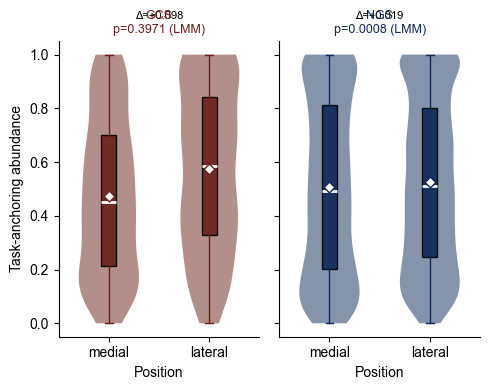

In [3]:

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

all_gcs['SC_x'] = np.abs(all_gcs['SC_x'])
all_ngs['SC_x'] = np.abs(all_ngs['SC_x'])
all_gcs['medial_lateral'] = np.where(all_gcs['SC_x'] < 3400, 'medial', 'lateral')
all_ngs['medial_lateral'] = np.where(all_ngs['SC_x'] < 3400, 'medial', 'lateral')

all_gcs['cell_type'] = 'GCS'
all_ngs['cell_type'] = 'NGS'
plot_df = pd.concat([all_gcs, all_ngs], ignore_index=True).dropna(
    subset=['task_anchoring_abundance', 'medial_lateral', 'mouse', 'day']
)
plot_df['mouse_day'] = plot_df['mouse'].astype(str) + '_' + plot_df['day'].astype(str)
plot_df['position_code'] = (plot_df['medial_lateral'] == 'lateral').astype(float)

cell_types = ['GCS', 'NGS']
positions  = ['medial', 'lateral']
colors     = {'GCS': '#69201a', 'NGS': '#0d2958'}

fig, axes = plt.subplots(1, 2, figsize=(5, 4), sharey=True)

for ax, cell_type in zip(axes, cell_types):
    ct_df = plot_df[plot_df['cell_type'] == cell_type].copy()
    color = colors[cell_type]

    group_vals = []
    group_means = []
    for x_pos, position in enumerate(positions):
        vals = ct_df[ct_df['medial_lateral'] == position]['task_anchoring_abundance'].dropna().values
        group_vals.append(vals)
        group_means.append(np.mean(vals))

        # Violin
        parts = ax.violinplot(vals, positions=[x_pos], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.5)

        # Box plot overlaid
        ax.boxplot(
            vals, positions=[x_pos], widths=0.15,
            patch_artist=True, showfliers=False,
            medianprops=dict(color='white', linewidth=2),
            boxprops=dict(facecolor=color, alpha=0.9),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
        )

        # Mean marker
        ax.scatter([x_pos], [group_means[-1]], color='white', s=30, zorder=5, marker='D',
                   edgecolors=color, linewidths=1)

    # Difference of means annotation
    diff = group_means[1] - group_means[0]  # lateral - medial
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else max(np.concatenate(group_vals))
    bracket_y = y_top * 1.05
    ax.annotate('', xy=(1, bracket_y), xytext=(0, bracket_y),
                arrowprops=dict(arrowstyle='-', color='black', lw=1))
    ax.text(0.5, bracket_y * 1.02, f'Δ={diff:+.3f}', ha='center', va='bottom',
            fontsize=8, color='black')

    # Linear mixed model
    try:
        lmm = smf.mixedlm(
            "task_anchoring_abundance ~ position_code",
            data=ct_df,
            groups=ct_df["mouse"],
            vc_formula={"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"},
        )
        res = lmm.fit(reml=False, method='lbfgs')
        p = res.pvalues['position_code']
        ax.set_title(f'{cell_type}\np={p:.4f} (LMM)', fontsize=9, color=color)
    except Exception as e:
        ax.set_title(f'{cell_type}\nLMM error', fontsize=9, color=color)
        print(f'{cell_type} LMM error: {e}')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(positions)
    ax.set_xlabel('Position')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel('Task-anchoring abundance')
plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_abundance_medial_lateral.pdf'
)
plt.show()


In [6]:
from scipy.stats import sem as scipy_sem

DOMINANCE_THRESHOLD = 0.9

def _lag1_autocorr(labels):
    v = labels[~np.isnan(labels.astype(float))]
    if len(v) < 3:
        return np.nan
    return float(np.corrcoef(v[:-1], v[1:])[0, 1])

def _mean_run_length(labels):
    v = labels[~np.isnan(labels.astype(float))].astype(int)
    if len(v) == 0:
        return np.nan
    runs, n = [], 1
    for i in range(1, len(v)):
        if v[i] == v[i - 1]:
            n += 1
        else:
            runs.append(n); n = 1
    runs.append(n)
    return float(np.mean(runs))

all_gcs_dfs2, all_ngs_dfs2 = [], []

for mouse, days in mouse_days.items():
    for day in days:
        print(f"M{mouse} D{day}...", end=' ')
        try:
            gcs, ngs, _ = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, _, _, last_ephys_bin, _, _ = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"SKIP ({e})"); continue
        print(f"{len(gcs)} GC  {len(ngs)} NGS")

        for cell_type, cell_df in [('GCS', gcs), ('NGS', ngs)]:
            if cell_df.empty:
                continue

            abundances, is_dominant, streakiness, mean_run_lengths = [], [], [], []

            for cid in cell_df.cluster_id.values:
                try:
                    if cid not in tcs:
                        raise ValueError("not in tcs")
                    tc = gaussian_filter(
                        np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5
                    )[:last_ephys_bin]
                    results   = spectral_analysis({cid: tc, 1000: tc}, tl, bs=bs)
                    S         = results[3].mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    label_idx = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels    = get_kmeans_spatial_labels(tc, label_idx, bs=bs, tl=tl)
                    valid     = labels[~np.isnan(labels.astype(float))]
                    abund     = float(np.mean(valid == 1)) if len(valid) > 0 else np.nan
                    dom       = bool(abund > DOMINANCE_THRESHOLD or
                                     abund < (1 - DOMINANCE_THRESHOLD))
                    abundances.append(abund)
                    is_dominant.append(dom)
                    streakiness.append(_lag1_autocorr(labels))
                    mean_run_lengths.append(_mean_run_length(labels))
                except Exception as e:
                    abundances.append(np.nan)
                    is_dominant.append(np.nan)
                    streakiness.append(np.nan)
                    mean_run_lengths.append(np.nan)

            out = cell_df.copy()
            out['mouse']                   = mouse
            out['day']                     = day
            out['task_anchoring_abundance'] = abundances
            out['is_dominant']             = is_dominant
            out['streakiness']             = streakiness
            out['mean_run_length']         = mean_run_lengths

            if cell_type == 'GCS':
                all_gcs_dfs2.append(out)
            else:
                all_ngs_dfs2.append(out)

all_gcs2 = pd.concat(all_gcs_dfs2, ignore_index=True)
all_ngs2 = pd.concat(all_ngs_dfs2, ignore_index=True)

for df in [all_gcs2, all_ngs2]:
    df['SC_x_abs']       = df['SC_x'].abs()
    df['medial_lateral'] = np.where(df['SC_x_abs'] < 3400, 'medial', 'lateral')

print(f"\nDone: {len(all_gcs2)} GC rows, {len(all_ngs2)} NGS rows")


M20 D14... 4 GC  109 NGS
M20 D15... 3 GC  50 NGS
M20 D16... 11 GC  165 NGS
M20 D17... 3 GC  70 NGS
M20 D18... 4 GC  105 NGS
M20 D19... 1 GC  91 NGS
M20 D20... 8 GC  88 NGS
M20 D21... 1 GC  70 NGS
M20 D22... 0 GC  61 NGS
M20 D23... 5 GC  61 NGS
M20 D24... 4 GC  68 NGS
M20 D25... 16 GC  18 NGS
M20 D26... 5 GC  106 NGS
M21 D15... 8 GC  193 NGS
M21 D16... 22 GC  172 NGS
M21 D17... 10 GC  208 NGS
M21 D18... 8 GC  150 NGS
M21 D19... 5 GC  244 NGS
M21 D20... 9 GC  177 NGS
M21 D21... 53 GC  131 NGS
M21 D22... 6 GC  100 NGS
M21 D23... 9 GC  188 NGS
M21 D24... 9 GC  126 NGS
M21 D25... 6 GC  71 NGS
M21 D26... 35 GC  107 NGS
M22 D33... 1 GC  82 NGS
M22 D34... 1 GC  4 NGS
M22 D35... 1 GC  7 NGS
M22 D36... 1 GC  59 NGS
M22 D37... 1 GC  40 NGS
M22 D38... 6 GC  105 NGS
M22 D39... 0 GC  0 NGS
M22 D40... 0 GC  0 NGS
M22 D41... 0 GC  0 NGS
M25 D16... 0 GC  26 NGS
M25 D17... 1 GC  15 NGS
M25 D18... 11 GC  111 NGS
M25 D19... 13 GC  37 NGS
M25 D20... 20 GC  31 NGS
M25 D21... 23 GC  24 NGS
M25 D22... 17 GC  

After ENTm filter: 628 GC cells, 5182 NGS cells


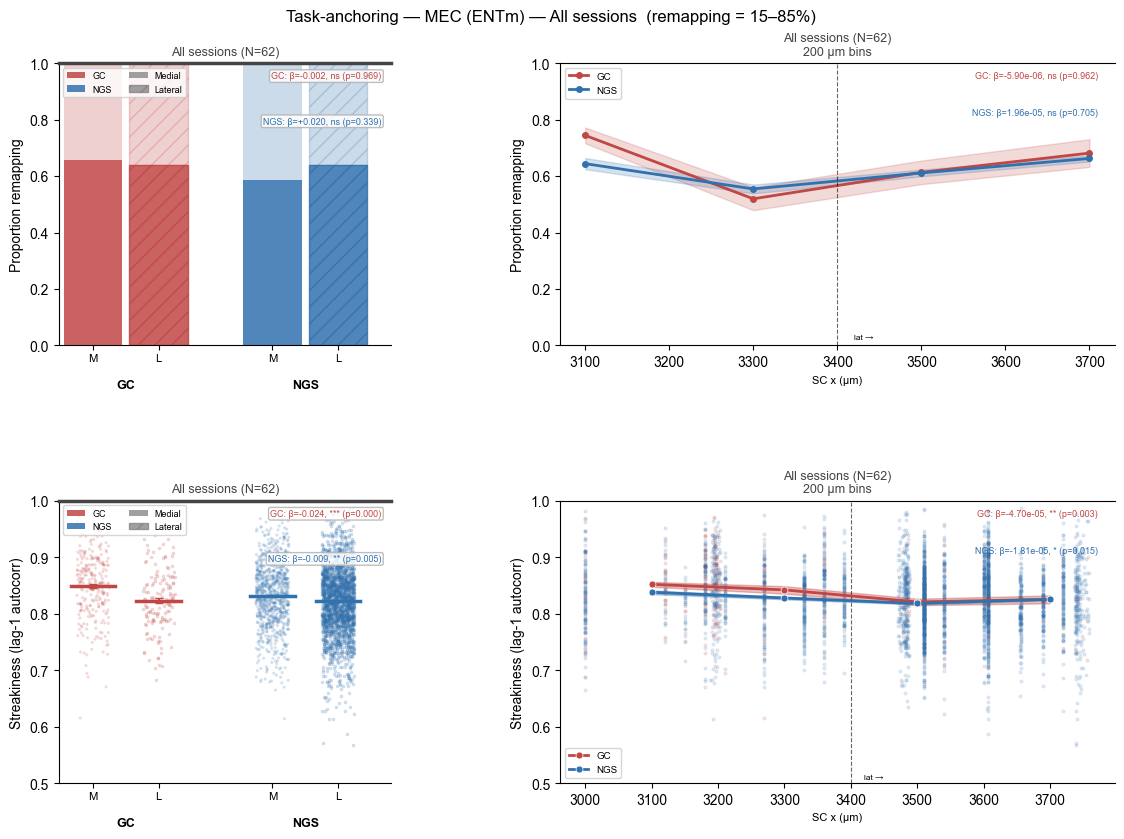

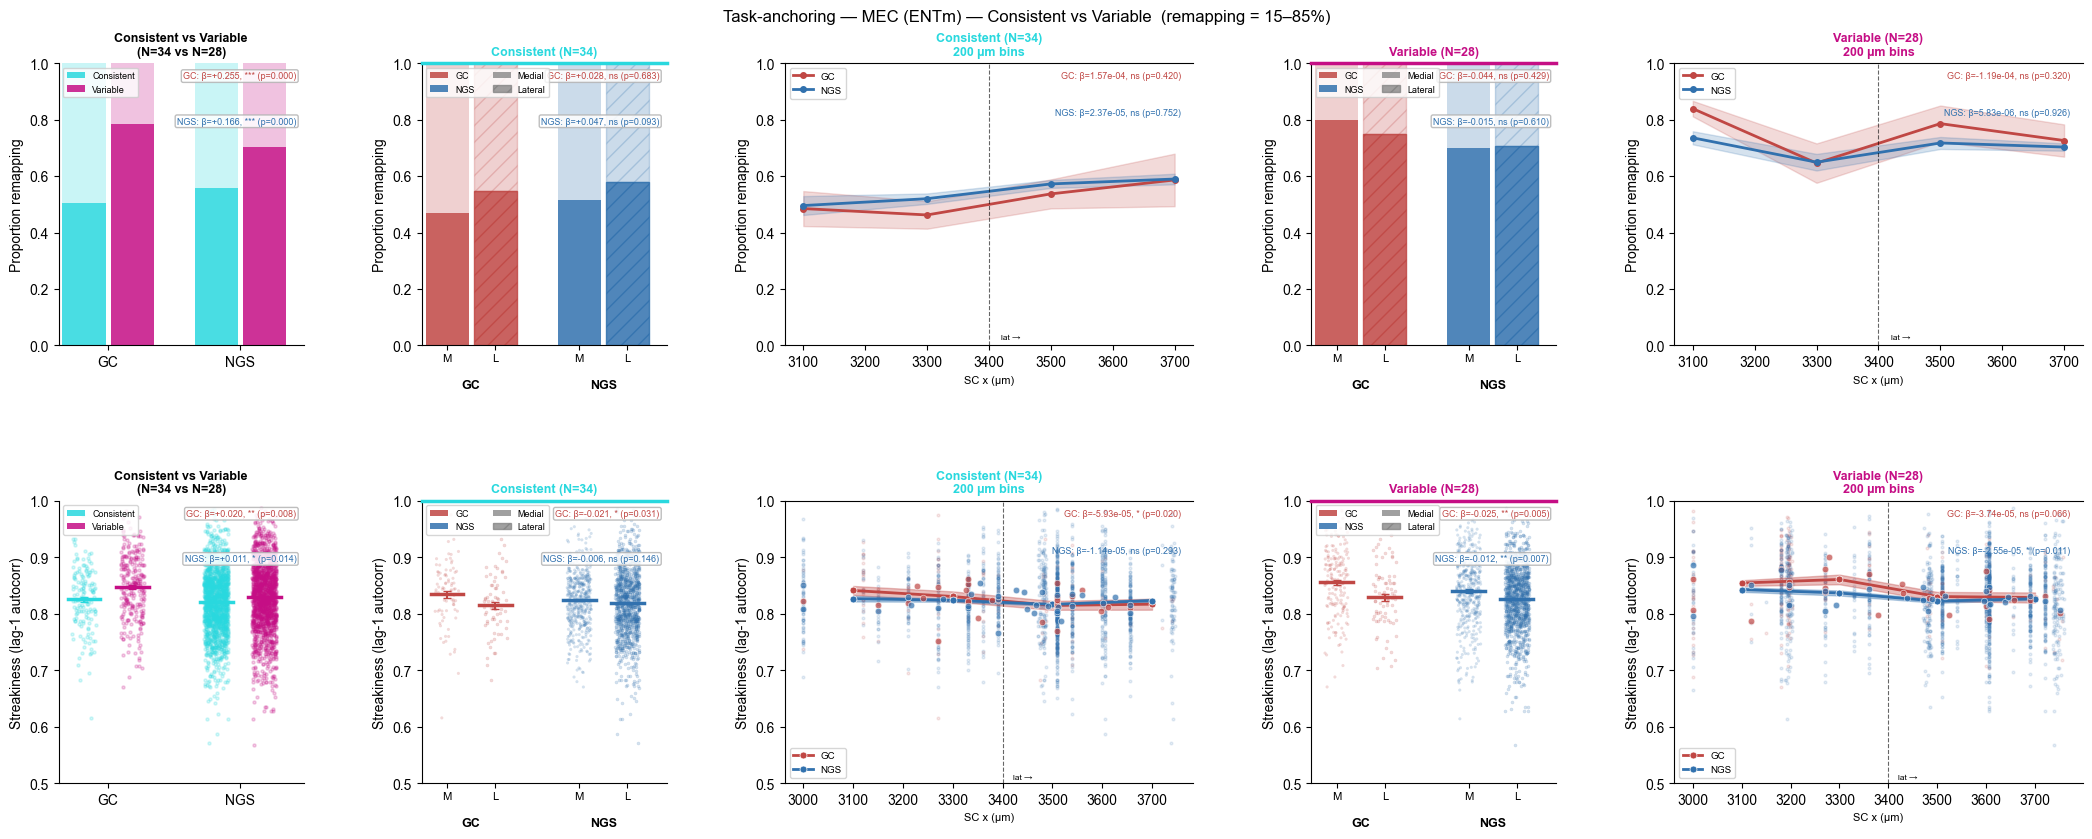

In [69]:
import statsmodels.formula.api as smf
from scipy.stats import sem as scipy_sem
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

gc_color  = '#c04744'
ngs_color = '#3171ae'
COLOR_CONSIST = '#29d8de'
COLOR_VAR     = '#C50E85'
MEDLAT_BOUNDARY     = 3400
DOMINANCE_THRESHOLD = 0.85

# ── Filter to MEC cells only ──────────────────────────────────────────────────
all_gcs2 = all_gcs2[all_gcs2['brain_region'].str.contains('ENTm', na=False)].copy()
all_ngs2 = all_ngs2[all_ngs2['brain_region'].str.contains('ENTm', na=False)].copy()
print(f"After ENTm filter: {len(all_gcs2)} GC cells, {len(all_ngs2)} NGS cells")

for df in [all_gcs2, all_ngs2]:
    df['SC_x_abs']       = df['SC_x'].abs()
    df['medial_lateral'] = np.where(df['SC_x_abs'] < MEDLAT_BOUNDARY, 'medial', 'lateral')
    df['position_code']  = (df['medial_lateral'] == 'lateral').astype(float)
    df['is_dominant']    = df['is_dominant'].astype(float)
    df['is_remapping']   = (
        (df['task_anchoring_abundance'] >= (1 - DOMINANCE_THRESHOLD)) &
        (df['task_anchoring_abundance'] <= DOMINANCE_THRESHOLD)
    ).astype(float)

datasets   = [(all_gcs2, gc_color, 'GC'), (all_ngs2, ngs_color, 'NGS')]
fine_edges = np.arange(2800, 3801, 200)
fine_ctrs  = (fine_edges[:-1] + fine_edges[1:]) / 2

# ── N sessions per condition ──────────────────────────────────────────────────
_sess = pd.concat([
    all_gcs2[['mouse', 'day', 'beh_group']],
    all_ngs2[['mouse', 'day', 'beh_group']],
]).drop_duplicates(subset=['mouse', 'day'])

n_all     = len(_sess)
n_consist = len(_sess[_sess['beh_group'] == 'consistent'])
n_var     = len(_sess[_sess['beh_group'] == 'variable'])

beh_conditions = [
    (None,         '#444444',     f'All sessions (N={n_all})'),
    ('consistent', COLOR_CONSIST, f'Consistent (N={n_consist})'),
    ('variable',   COLOR_VAR,     f'Variable (N={n_var})'),
]

# ── bar / scatter x positions (slightly tighter) ──────────────────────────────
BAR_W          = 0.17
x_med          = np.array([0.0,  0.52])
x_lat          = np.array([0.19, 0.71])
xtick_pos_comb = [(x_med[i] + x_lat[i]) / 2 for i in range(2)]
xlim_comb      = (-0.10, x_lat[-1] + BAR_W / 2 + 0.07)

CV_W         = 0.17
cv_consist   = np.array([0.0,  0.52])
cv_var       = np.array([0.19, 0.71])
xtick_pos_cv = [(cv_consist[i] + cv_var[i]) / 2 for i in range(2)]
xlim_cv      = (-0.10, cv_var[-1] + CV_W / 2 + 0.07)

_comb_legend = [
    Patch(fc=gc_color,  alpha=0.85, label='GC'),
    Patch(fc=ngs_color, alpha=0.85, label='NGS'),
    Patch(fc='grey', alpha=0.75, label='Medial'),
    Patch(fc='grey', alpha=0.75, hatch='//', ec='grey', label='Lateral'),
]
_cv_legend = [
    Patch(fc=COLOR_CONSIST, alpha=0.85, label='Consistent'),
    Patch(fc=COLOR_VAR,     alpha=0.85, label='Variable'),
]


def _sig_stars(p):
    if p is None or np.isnan(p): return 'n.d.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _fit_lmm(df, outcome):
    sub = df[['mouse', 'day', 'cluster_id', 'position_code', outcome]].copy()
    sub[outcome] = sub[outcome].astype(float)
    sub = sub.dropna()
    if len(sub) < 10: return np.nan, np.nan
    try:
        res = smf.mixedlm(
            f"{outcome} ~ position_code", data=sub, groups=sub['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        ).fit(reml=False, method='lbfgs', disp=False)
        return float(res.params['position_code']), float(res.pvalues['position_code'])
    except Exception as e:
        print(f"  LMM [{outcome}] failed: {e}")
        return np.nan, np.nan

def _fit_lmm_continuous(df, outcome):
    sub = df[['mouse', 'day', 'cluster_id', 'SC_x_abs', outcome]].copy()
    sub[outcome] = sub[outcome].astype(float)
    sub = sub.dropna()
    if len(sub) < 10: return np.nan, np.nan
    try:
        res = smf.mixedlm(
            f"{outcome} ~ SC_x_abs", data=sub, groups=sub['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        ).fit(reml=False, method='lbfgs', disp=False)
        return float(res.params['SC_x_abs']), float(res.pvalues['SC_x_abs'])
    except Exception as e:
        print(f"  LMM continuous [{outcome}] failed: {e}")
        return np.nan, np.nan

def _fit_lmm_beh(df, outcome):
    sub = df[['mouse', 'day', 'cluster_id', 'beh_group', outcome]].copy()
    sub = sub[sub['beh_group'].notna()]
    sub[outcome] = sub[outcome].astype(float)
    sub = sub.dropna()
    if len(sub) < 10: return np.nan, np.nan
    try:
        res = smf.mixedlm(
            f"{outcome} ~ beh_group", data=sub, groups=sub['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        ).fit(reml=False, method='lbfgs', disp=False)
        key = [k for k in res.params.index if 'beh_group' in k][0]
        return float(res.params[key]), float(res.pvalues[key])
    except Exception as e:
        print(f"  LMM beh [{outcome}] failed: {e}")
        return np.nan, np.nan

def _filter(df, cond_val):
    return df.copy() if cond_val is None else df[df['beh_group'] == cond_val].copy()

def _mixed_cells(df, cond_val=None):
    sub = _filter(df, cond_val)
    return sub[
        (sub['task_anchoring_abundance'] >= (1 - DOMINANCE_THRESHOLD)) &
        (sub['task_anchoring_abundance'] <= DOMINANCE_THRESHOLD)
    ].copy()

def _apply_ml_xticks(ax):
    ax.set_xticks([x_med[0], x_lat[0], x_med[1], x_lat[1]])
    ax.set_xticklabels(['M', 'L', 'M', 'L'], fontsize=8)
    ax.tick_params(axis='x', pad=2)
    for xi_t, cell_lbl in [(xtick_pos_comb[0], 'GC'), (xtick_pos_comb[1], 'NGS')]:
        ax.text(xi_t, -0.12, cell_lbl, transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=9, fontweight='bold', color='k', clip_on=False)


# ── Row 0: Proportion remapping cells ─────────────────────────────────────────
def _plot_dom_combined_bars(ax, cond_val, cond_color):
    for ci, (df, color, _) in enumerate(datasets):
        sub_df = _filter(df, cond_val)
        for pos, xi, hatch in [('medial', x_med[ci], None), ('lateral', x_lat[ci], '//')]:
            sub = sub_df[sub_df['medial_lateral'] == pos]['is_remapping'].dropna()
            fr  = float(np.mean(sub)) if len(sub) > 0 else np.nan
            if np.isnan(fr): continue
            ec = color if hatch else 'none'
            ax.bar(xi, fr,       color=color, alpha=0.85, width=BAR_W, hatch=hatch, edgecolor=ec)
            ax.bar(xi, 1.0 - fr, bottom=fr, color=color, alpha=0.25, width=BAR_W, hatch=hatch, edgecolor=ec)
    for i, (df, color, label) in enumerate(datasets):
        coef, p = _fit_lmm(_filter(df, cond_val), 'is_remapping')
        ax.text(0.97, 0.97 - 0.16 * i,
                f'{label}: β={coef:+.3f}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85))
    ax.set_xlim(*xlim_comb); ax.set_ylim(0, 1.0)
    ax.set_ylabel('Proportion remapping')
    ax.legend(handles=_comb_legend, fontsize=6.5, loc='upper left', ncol=2)
    ax.spines['top'].set_visible(True); ax.spines['top'].set_color(cond_color)
    ax.spines['top'].set_linewidth(2.5); ax.spines['right'].set_visible(False)
    _apply_ml_xticks(ax)

def _plot_dom_bins(ax, datasets_list, cond_color):
    for i, (df, color, label) in enumerate(datasets_list):
        means, sems = [], []
        for lo, hi in zip(fine_edges[:-1], fine_edges[1:]):
            sub = df[(df['SC_x_abs'] >= lo) & (df['SC_x_abs'] < hi)
                     ]['is_remapping'].astype(float).dropna()
            means.append(float(np.mean(sub)) if len(sub) >= 3 else np.nan)
            sems.append(float(scipy_sem(sub)) if len(sub) >= 3 else np.nan)
        means, sems = np.array(means), np.array(sems)
        valid = ~np.isnan(means)
        ax.fill_between(fine_ctrs[valid], means[valid] - sems[valid],
                        means[valid] + sems[valid], color=color, alpha=0.2)
        ax.plot(fine_ctrs[valid], means[valid], '-o', color=color,
                linewidth=2, markersize=4, label=label)
        coef, p = _fit_lmm_continuous(df, 'is_remapping')
        ax.text(0.97, 0.97 - 0.13 * i,
                f'{label}: β={coef:.2e}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color)
    ax.axvline(MEDLAT_BOUNDARY, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(MEDLAT_BOUNDARY + 20, 0.02, 'lat →', fontsize=6, va='bottom')
    ax.set_ylim(0, 1.0); ax.set_xlabel('SC x (µm)', fontsize=8)
    ax.set_ylabel('Proportion remapping')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(True); ax.spines['right'].set_visible(False)

def _plot_dom_cv_comparison(ax):
    for ci, (df, color, _) in enumerate(datasets):
        for cond_val, xi, cond_color in [('consistent', cv_consist[ci], COLOR_CONSIST),
                                          ('variable',   cv_var[ci],     COLOR_VAR)]:
            sub = _filter(df, cond_val)['is_remapping'].dropna()
            fr  = float(np.mean(sub)) if len(sub) > 0 else np.nan
            if np.isnan(fr): continue
            ax.bar(xi, fr,       color=cond_color, alpha=0.85, width=CV_W)
            ax.bar(xi, 1.0 - fr, bottom=fr, color=cond_color, alpha=0.25, width=CV_W)
    for i, (df, color, label) in enumerate(datasets):
        coef, p = _fit_lmm_beh(df, 'is_remapping')
        ax.text(0.97, 0.97 - 0.16 * i,
                f'{label}: β={coef:+.3f}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85))
    ax.set_xticks(xtick_pos_cv); ax.set_xticklabels(['GC', 'NGS'])
    ax.set_xlim(*xlim_cv); ax.set_ylim(0, 1.0)
    ax.set_ylabel('Proportion remapping')
    ax.legend(handles=_cv_legend, fontsize=6.5, loc='upper left')
    ax.set_title(f'Consistent vs Variable\n(N={n_consist} vs N={n_var})', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


# ── Row 1: Per-cell streakiness ───────────────────────────────────────────────
def _plot_cell_scatter_comb(ax, outcome, ylabel, cond_val, cond_color):
    rng = np.random.default_rng(42)
    for ci, (df, color, _) in enumerate(datasets):
        mixed = _mixed_cells(df, cond_val)
        for pos, xi, hatch in [('medial', x_med[ci], None), ('lateral', x_lat[ci], '//')]:
            vals = mixed[mixed['medial_lateral'] == pos][outcome].dropna().values
            if len(vals) == 0: continue
            xs = xi + rng.uniform(-BAR_W * 0.28, BAR_W * 0.28, len(vals))
            ec = color if hatch else 'none'
            ax.scatter(xs, vals, color=color, alpha=0.20, s=5,
                       edgecolors=ec, linewidths=0.3, zorder=2, rasterized=True)
            m = np.mean(vals)
            ax.plot([xi - BAR_W * 0.38, xi + BAR_W * 0.38], [m, m],
                    color=color, linewidth=2.5, zorder=4)
            if len(vals) >= 3:
                ax.errorbar(xi, m, yerr=scipy_sem(vals), fmt='none',
                            ecolor=color, capsize=3, linewidth=1.5, zorder=5)
    for i, (df, color, label) in enumerate(datasets):
        coef, p = _fit_lmm(_mixed_cells(df, cond_val), outcome)
        ax.text(0.97, 0.97 - 0.16 * i,
                f'{label}: β={coef:+.3f}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85))
    ax.set_xlim(*xlim_comb)
    ax.set_ylabel(ylabel)
    ax.legend(handles=_comb_legend, fontsize=6.5, loc='upper left', ncol=2)
    ax.spines['top'].set_visible(True); ax.spines['top'].set_color(cond_color)
    ax.spines['top'].set_linewidth(2.5); ax.spines['right'].set_visible(False)
    _apply_ml_xticks(ax)

def _plot_cell_bins(ax, outcome, ylabel, datasets_list, cond_color, show_session_scatter=False):
    for i, (df, color, label) in enumerate(datasets_list):
        mixed = df[
            (df['task_anchoring_abundance'] >= (1 - DOMINANCE_THRESHOLD)) &
            (df['task_anchoring_abundance'] <= DOMINANCE_THRESHOLD)
        ].copy()
        # per-cell scatter
        cell_xy = mixed[['SC_x_abs', outcome]].dropna()
        ax.scatter(cell_xy['SC_x_abs'], cell_xy[outcome],
                   color=color, alpha=0.12, s=4, zorder=1, rasterized=True)
        # per-session mean scatter
        if show_session_scatter:
            sess = (mixed.groupby(['mouse', 'day'])[['SC_x_abs', outcome]]
                    .mean().dropna().reset_index())
            ax.scatter(sess['SC_x_abs'], sess[outcome],
                       color=color, alpha=0.70, s=22, zorder=5, rasterized=True,
                       edgecolors='white', linewidths=0.5)
        # bin means ± SEM
        means, sems_v = [], []
        for lo, hi in zip(fine_edges[:-1], fine_edges[1:]):
            sub = mixed[(mixed['SC_x_abs'] >= lo) & (mixed['SC_x_abs'] < hi)
                        ][outcome].dropna()
            means.append(float(np.mean(sub)) if len(sub) >= 3 else np.nan)
            sems_v.append(float(scipy_sem(sub)) if len(sub) >= 3 else np.nan)
        means, sems_v = np.array(means), np.array(sems_v)
        valid = ~np.isnan(means)
        ax.fill_between(fine_ctrs[valid], means[valid] - sems_v[valid],
                        means[valid] + sems_v[valid], color=color, alpha=0.35, zorder=2)
        ax.plot(fine_ctrs[valid], means[valid], '-o', color=color,
                linewidth=2, markersize=5, label=label, zorder=3,
                markeredgecolor='white', markeredgewidth=0.5)
        coef, p = _fit_lmm_continuous(mixed, outcome)
        ax.text(0.97, 0.97 - 0.13 * i,
                f'{label}: β={coef:.2e}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color)
    ax.axvline(MEDLAT_BOUNDARY, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(MEDLAT_BOUNDARY + 20, 0.01, 'lat →', fontsize=6, va='bottom',
            transform=ax.get_xaxis_transform())
    ax.set_xlabel('SC x (µm)', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(True); ax.spines['right'].set_visible(False)

def _plot_cell_cv(ax, outcome, ylabel):
    rng = np.random.default_rng(42)
    for ci, (df, color, _) in enumerate(datasets):
        mixed = _mixed_cells(df)
        for cond_val, xi, cond_color in [('consistent', cv_consist[ci], COLOR_CONSIST),
                                          ('variable',   cv_var[ci],     COLOR_VAR)]:
            vals = _filter(mixed, cond_val)[outcome].dropna().values
            if len(vals) == 0: continue
            xs = xi + rng.uniform(-CV_W * 0.28, CV_W * 0.28, len(vals))
            ax.scatter(xs, vals, color=cond_color, alpha=0.20, s=5, zorder=2, rasterized=True)
            m = np.mean(vals)
            ax.plot([xi - CV_W * 0.38, xi + CV_W * 0.38], [m, m],
                    color=cond_color, linewidth=2.5, zorder=4)
            if len(vals) >= 3:
                ax.errorbar(xi, m, yerr=scipy_sem(vals), fmt='none',
                            ecolor=cond_color, capsize=3, linewidth=1.5, zorder=5)
    for i, (df, color, label) in enumerate(datasets):
        coef, p = _fit_lmm_beh(_mixed_cells(df), outcome)
        ax.text(0.97, 0.97 - 0.16 * i,
                f'{label}: β={coef:+.3f}, {_sig_stars(p)} (p={p:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.5, color=color,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85))
    ax.set_xticks(xtick_pos_cv); ax.set_xticklabels(['GC', 'NGS'])
    ax.set_xlim(*xlim_cv)
    ax.set_ylabel(ylabel)
    ax.legend(handles=_cv_legend, fontsize=6.5, loc='upper left')
    ax.set_title(f'Consistent vs Variable\n(N={n_consist} vs N={n_var})', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


# ── Figure 1: All sessions — 2 rows × 2 cols ─────────────────────────────────
cond_val_all, cond_color_all, cond_label_all = beh_conditions[0]
cond_datasets_all = [(_filter(df, cond_val_all), color, label) for df, color, label in datasets]

fig1 = plt.figure(figsize=(12, 9))
gs1  = gridspec.GridSpec(2, 2, figure=fig1,
                          width_ratios=[3, 5],
                          hspace=0.55, wspace=0.38,
                          left=0.09, right=0.97, top=0.92, bottom=0.12)
ax1 = np.array([[fig1.add_subplot(gs1[r, c]) for c in range(2)] for r in range(2)])

_plot_dom_combined_bars(ax1[0, 0], cond_val_all, cond_color_all)
ax1[0, 0].set_title(cond_label_all, color=cond_color_all, fontsize=9)
_plot_dom_bins(ax1[0, 1], cond_datasets_all, cond_color_all)
ax1[0, 1].set_title(f'{cond_label_all}\n200 µm bins', color=cond_color_all, fontsize=9)

_plot_cell_scatter_comb(ax1[1, 0], 'streakiness', 'Streakiness (lag-1 autocorr)',
                        cond_val_all, cond_color_all)
ax1[1, 0].set_ylim(0.5, 1.0)
ax1[1, 0].set_title(cond_label_all, color=cond_color_all, fontsize=9)
_plot_cell_bins(ax1[1, 1], 'streakiness', 'Streakiness (lag-1 autocorr)',
               cond_datasets_all, cond_color_all, show_session_scatter=False)
ax1[1, 1].set_ylim(0.5, 1.0)
ax1[1, 1].set_title(f'{cond_label_all}\n200 µm bins', color=cond_color_all, fontsize=9)

fig1.suptitle(f'Task-anchoring — MEC (ENTm) — All sessions  '
              f'(remapping = {(1-DOMINANCE_THRESHOLD)*100:.0f}–{DOMINANCE_THRESHOLD*100:.0f}%)', fontsize=12)
fig1.savefig('task_anchoring_medlat_all_sessions_ENTm.pdf', dpi=300, bbox_inches='tight')
plt.show()


# ── Figure 2: Consistent vs Variable — 2 rows × 5 cols ───────────────────────
fig2 = plt.figure(figsize=(22, 9))
gs2  = gridspec.GridSpec(2, 5, figure=fig2,
                          width_ratios=[3, 3, 5, 3, 5],
                          hspace=0.55, wspace=0.38,
                          left=0.06, right=0.98, top=0.92, bottom=0.12)
ax2 = np.array([[fig2.add_subplot(gs2[r, c]) for c in range(5)] for r in range(2)])

fig2_col_map = {1: (1, 2), 2: (3, 4)}

for cond_idx in [1, 2]:
    cond_val, cond_color, cond_label = beh_conditions[cond_idx]
    bar_col, bin_col = fig2_col_map[cond_idx]
    cond_datasets = [(_filter(df, cond_val), color, label) for df, color, label in datasets]

    _plot_dom_combined_bars(ax2[0, bar_col], cond_val, cond_color)
    ax2[0, bar_col].set_title(cond_label, color=cond_color, fontsize=9, fontweight='bold')
    _plot_dom_bins(ax2[0, bin_col], cond_datasets, cond_color)
    ax2[0, bin_col].set_title(f'{cond_label}\n200 µm bins', color=cond_color, fontsize=9, fontweight='bold')

    _plot_cell_scatter_comb(ax2[1, bar_col], 'streakiness', 'Streakiness (lag-1 autocorr)',
                            cond_val, cond_color)
    ax2[1, bar_col].set_ylim(0.5, 1.0)
    ax2[1, bar_col].set_title(cond_label, color=cond_color, fontsize=9, fontweight='bold')
    # show_session_scatter=True for the 3rd and 5th columns (bin_col = 2 and 4)
    _plot_cell_bins(ax2[1, bin_col], 'streakiness', 'Streakiness (lag-1 autocorr)',
                   cond_datasets, cond_color, show_session_scatter=True)
    ax2[1, bin_col].set_ylim(0.5, 1.0)
    ax2[1, bin_col].set_title(f'{cond_label}\n200 µm bins', color=cond_color, fontsize=9, fontweight='bold')

_plot_dom_cv_comparison(ax2[0, 0])
_plot_cell_cv(ax2[1, 0], 'streakiness', 'Streakiness (lag-1 autocorr)')
ax2[1, 0].set_ylim(0.5, 1.0)

fig2.suptitle(f'Task-anchoring — MEC (ENTm) — Consistent vs Variable  '
              f'(remapping = {(1-DOMINANCE_THRESHOLD)*100:.0f}–{DOMINANCE_THRESHOLD*100:.0f}%)', fontsize=12)
fig2.savefig('task_anchoring_medlat_consist_var_ENTm.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Task-anchoring remapping and streakiness: conceptual framework

### What each metric captures

**Remapping proportion** (`task_anchoring_abundance` ∈ [0.15, 0.85]): the fraction of cells that genuinely alternate between an *anchored* state — where firing is locked to the task structure — and a *non-anchored* state, where firing is decoupled from the task. Dominant cells (>0.85) are stably anchored; cells below 0.15 are stably non-anchored. Remapping cells occupy a mixed regime, switching between the two states across trials.

**Streakiness** (lag-1 autocorrelation of per-trial anchoring labels): measures the *temporal structure* of anchoring-state transitions in remapping cells. A value near 1 means consecutive trials are highly likely to share the same state — the cell stays anchored (or non-anchored) for extended runs before switching. A value near 0.5 means near-random trial-by-trial alternation. Streakiness is only interpretable for remapping cells; cells with dominant labels have near-constant trial sequences and give trivially high autocorrelation.

### Why the two metrics must be read together

| Remapping proportion | Streakiness | Interpretation |
|---|---|---|
| Low | — | Most cells are stably committed to one anchoring state |
| High | Low (~0.5) | Cells switch anchoring state often but without structure — possibly driven by fast noise or trial-level fluctuations |
| High | High (→1) | Cells switch in extended, coherent runs — driven by a slowly-varying internal or network state |

High remapping proportion *combined with* high streakiness is the most interpretable regime: it implies that transitions between anchored and non-anchored states are not random but are organised into multi-trial epochs. This is consistent with network attractor dynamics, where the MEC population settles into one anchoring mode for a run of trials before transitioning, possibly driven by a slowly changing behavioural or cognitive state.

### Medial–lateral gradient

A significant medial–lateral gradient in remapping proportion would suggest that medial cells are more susceptible to switching their anchoring state. A gradient in streakiness would additionally indicate that the *stability* of anchoring epochs varies along this axis — lateral cells spending longer coherent stretches in one mode, or conversely being more volatile.

### Consistent vs variable sessions

Sessions are split at the median uncued (`nb`) rolling hit-rate standard deviation:
- **Consistent sessions**: the animal sustains a steady level of task engagement.
- **Variable sessions**: the animal alternates between bouts of high and low engagement.

**Expected effects if anchoring state tracks task engagement:**
- *Remapping proportion* should be higher in variable sessions — more cells enter the mixed regime because the fluctuating behavioural state pushes the network in and out of task-anchoring more often.
- *Streakiness* should also be higher in variable sessions — behavioural bouts (extended stretches of high or low engagement) should manifest as long coherent runs of a single anchoring state, elevating the lag-1 autocorrelation.

If both are elevated in variable sessions, it supports a model in which MEC anchoring state reflects ongoing task engagement rather than being a fixed property of the cell, with the temporal dynamics of switching (streakiness) mirroring the timescale of behavioural fluctuations.


  M20 D14:  b=0.1071  nb=0.1779
  M20 D15:  b=0.2522  nb=0.0625
  M20 D16:  b=0.3011  nb=0.0955
  M20 D17:  b=0.2243  nb=0.0465
  M20 D18:  b=0.1682  nb=0.0458
  M20 D19:  b=0.2492  nb=0.0960
  M20 D20:  b=0.2540  nb=0.0894
  M20 D21:  b=0.2576  nb=0.0359
  M20 D22:  b=0.1542  nb=0.0392
  M20 D23:  b=0.2836  nb=0.1432
  M20 D24:  b=0.2931  nb=0.0725
  M20 D25:  b=0.2213  nb=0.0749
  M20 D26:  b=0.1597  nb=0.0901
  M21 D15:  b=0.1870  nb=0.0890
  M21 D16:  b=0.1694  nb=0.2006
  M21 D17:  b=0.1154  nb=0.2523
  M21 D18:  b=0.1206  nb=0.1383
  M21 D19:  b=0.2527  nb=0.3226
  M21 D20:  b=0.1369  nb=0.1567
  M21 D21:  b=0.0804  nb=0.3018
  M21 D22:  b=0.0442  nb=0.2611
  M21 D23:  b=0.0191  nb=0.1984
  M21 D24:  b=0.0485  nb=0.1865
  M21 D25:  b=0.0660  nb=0.1949
  M21 D26:  b=0.0445  nb=0.2535
  M22 D33:  b=0.0666  nb=0.1581
  M22 D34:  b=0.0587  nb=0.1831
  M22 D35:  b=0.0715  nb=0.0598
  M22 D36:  b=0.0343  nb=0.2020
  M22 D37:  b=0.1269  nb=0.2679
  M22 D38:  b=0.1021  nb=0.2342
  M22 D3

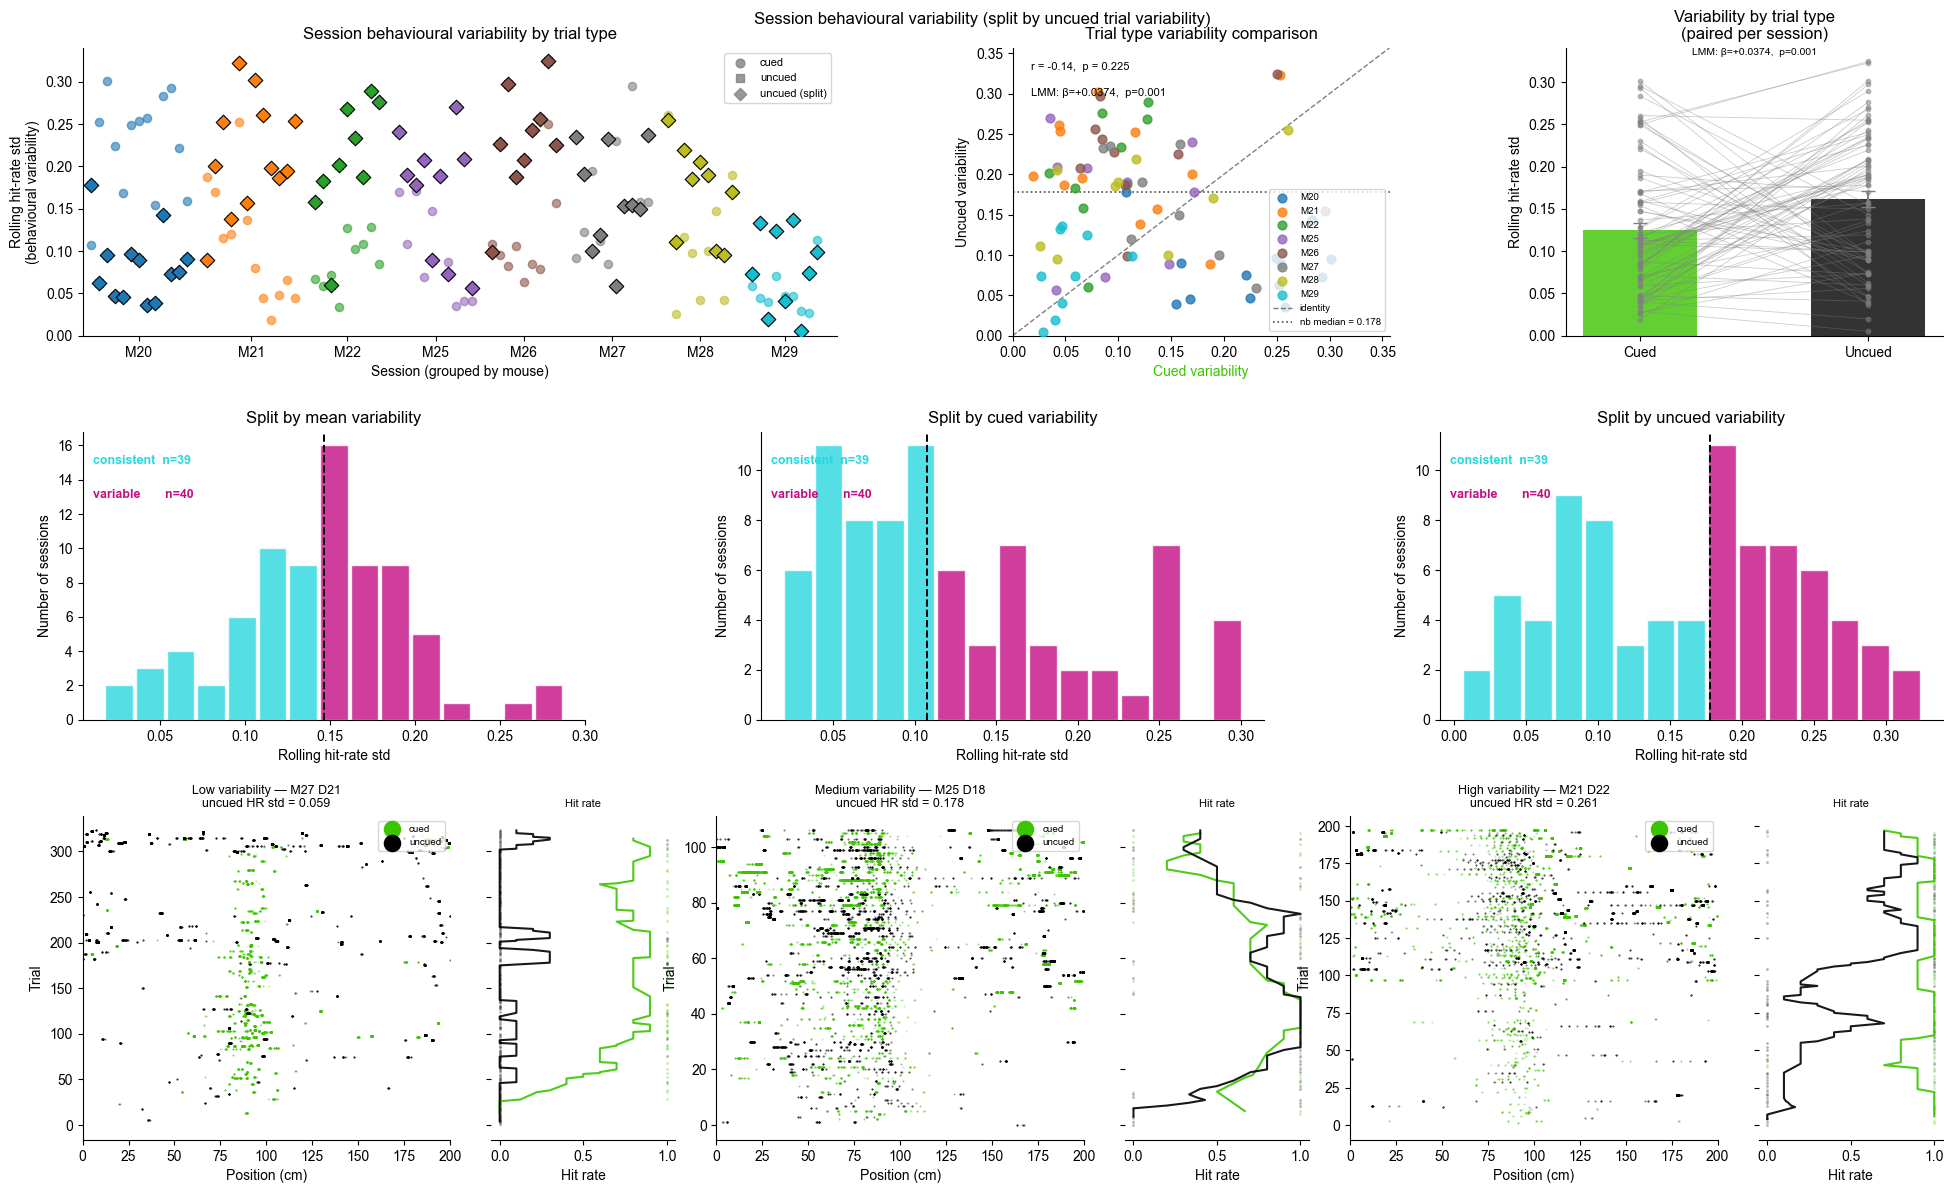

In [59]:
# --- Compute rolling hit-rate variability per session, split by trial type ---
from scipy.stats import sem as scipy_sem, pearsonr
import statsmodels.formula.api as smf
import matplotlib.gridspec as gridspec

TRIAL_TYPES   = ['b', 'nb']
COLOR_B       = '#3bc500'
COLOR_NB      = 'black'
COLOR_CONSIST = '#29d8de'
COLOR_VAR     = '#C50E85'

session_variability  = {}
session_var_by_type  = {}

for mouse, days in mouse_days.items():
    for day in days:
        try:
            vr_folder = f'{source_path}M{mouse}/D{day:02}/VR/'
            beh_path  = vr_folder + f"sub-{mouse}_day-{day:02}_ses-VR_beh.nwb"
            beh       = nap.load_file(beh_path)
            trials    = beh['trials']

            type_vars = {}
            for tt in TRIAL_TYPES:
                mask = trials['type'] == tt
                perf = trials['performance'][mask]
                hits = (perf == 'hit').astype(float).values
                if len(hits) < 10:
                    type_vars[tt] = np.nan
                    continue
                rolling_hr    = pd.Series(hits).rolling(20, min_periods=5).mean().dropna().values
                type_vars[tt] = float(np.std(rolling_hr))

            session_var_by_type[(mouse, day)] = type_vars
            session_variability[(mouse, day)] = type_vars.get('nb', np.nan)  # uncued only
            print(f"  M{mouse} D{day}:  b={type_vars.get('b', np.nan):.4f}  "
                  f"nb={type_vars.get('nb', np.nan):.4f}")

        except Exception as e:
            session_variability[(mouse, day)]  = np.nan
            session_var_by_type[(mouse, day)]  = {tt: np.nan for tt in TRIAL_TYPES}
            print(f"  M{mouse} D{day}: FAILED — {e}")

valid_vars = [v for v in session_variability.values() if not np.isnan(v)]
median_var = float(np.median(valid_vars))
print(f"\nMedian uncued session variability: {median_var:.3f}  (n={len(valid_vars)} sessions)")

for df in [all_gcs2, all_ngs2]:
    df['beh_variability'] = [
        session_variability.get((int(r['mouse']), int(r['day'])), np.nan)
        for _, r in df.iterrows()
    ]
    df['beh_group'] = np.where(
        df['beh_variability'] >= median_var, 'variable', 'consistent'
    )
    df.loc[df['beh_variability'].isna(), 'beh_group'] = None

print(f"\nall_gcs2 — variable: {(all_gcs2['beh_group']=='variable').sum()}  "
      f"consistent: {(all_gcs2['beh_group']=='consistent').sum()}  "
      f"excluded (NaN): {all_gcs2['beh_group'].isna().sum()}")
print(f"all_ngs2 — variable: {(all_ngs2['beh_group']=='variable').sum()}  "
      f"consistent: {(all_ngs2['beh_group']=='consistent').sum()}  "
      f"excluded (NaN): {all_ngs2['beh_group'].isna().sum()}")

# Collect paired b / nb values and LMM DataFrame
b_vals, nb_vals, pt_colors = [], [], []
lmm_rows   = []
mouse_ids  = sorted(mouse_days.keys())
mouse_colors = plt.cm.tab10(np.linspace(0, 1, len(mouse_ids)))
color_map  = dict(zip(mouse_ids, mouse_colors))

for mouse in mouse_ids:
    for day in mouse_days[mouse]:
        type_vs = session_var_by_type.get((mouse, day), {})
        bv  = type_vs.get('b',  np.nan)
        nbv = type_vs.get('nb', np.nan)
        if not np.isnan(bv) and not np.isnan(nbv):
            b_vals.append(bv); nb_vals.append(nbv)
            pt_colors.append(color_map[mouse])
        for tt_code, tt in [(0, 'b'), (1, 'nb')]:
            v = type_vs.get(tt, np.nan)
            if not np.isnan(v):
                lmm_rows.append({'mouse': mouse,
                                  'trial_type_code': float(tt_code),
                                  'variability': v})

b_vals  = np.array(b_vals)
nb_vals = np.array(nb_vals)

lmm_df = pd.DataFrame(lmm_rows)
try:
    lmm_res  = smf.mixedlm("variability ~ trial_type_code",
                            data=lmm_df, groups=lmm_df['mouse']
                            ).fit(reml=False, method='lbfgs', disp=False)
    lmm_coef = float(lmm_res.params['trial_type_code'])
    lmm_p    = float(lmm_res.pvalues['trial_type_code'])
    lmm_str  = f'LMM: β={lmm_coef:+.4f},  p={lmm_p:.3f}'
except Exception as e:
    lmm_str  = f'LMM failed: {e}'
    lmm_coef, lmm_p = np.nan, np.nan

print(f"\n{lmm_str}")

# ── Pick 3 example sessions by uncued variability ────────────────────────────
sorted_sessions = sorted(
    [(k, v) for k, v in session_variability.items() if not np.isnan(v)],
    key=lambda x: x[1]
)
n = len(sorted_sessions)
example_sessions = [
    ('low',    sorted_sessions[max(0, n // 10)]),
    ('medium', sorted_sessions[n // 2]),
    ('high',   sorted_sessions[min(n - 1, 9 * n // 10)]),
]
print("\nExample sessions (by uncued variability):")
for label, ((mouse, day), var) in example_sessions:
    print(f"  {label:6s}: M{mouse} D{day}  nb_variability={var:.4f}")


def _plot_stop_raster(ax, beh):
    trial_numbers = np.array(beh['trial_number'])
    position      = np.array(beh['P'])
    speed         = np.array(beh['S'])
    stop_mask     = speed < 3

    min_len       = min(len(trial_numbers), len(position), len(stop_mask))
    trial_numbers = trial_numbers[:min_len]
    position      = position[:min_len]
    stop_mask     = stop_mask[:min_len]

    for i, ti in enumerate(beh['trials'].index):
        t_num   = beh['trials'][ti]['number'].iloc[0]
        t_type  = beh['trials'][ti]['type'].iloc[0]
        tn_mask = trial_numbers == t_num
        stops   = position[stop_mask & tn_mask]
        if len(stops) == 0:
            continue
        color = COLOR_B if t_type == 'b' else COLOR_NB
        ax.scatter(stops, i * np.ones(len(stops)),
                   c=color, s=2, alpha=0.3, rasterized=True, linewidths=0)

    ax.set_xlim(0, tl)
    ax.invert_yaxis()
    ax.scatter([], [], c=COLOR_B,  s=15, label='cued')
    ax.scatter([], [], c=COLOR_NB, s=15, label='uncued')
    ax.legend(fontsize=7, loc='upper right', markerscale=3)
    ax.set_xlabel('Position (cm)')
    ax.set_ylabel('Trial')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)


def _plot_rolling_hr(ax, beh):
    for tt, color in [('b', COLOR_B), ('nb', COLOR_NB)]:
        tt_indices, tt_hits = [], []
        for i, ti in enumerate(beh['trials'].index):
            t_type = beh['trials'][ti]['type'].iloc[0]
            t_perf = beh['trials'][ti]['performance'].iloc[0]
            if t_type == tt:
                tt_indices.append(i)
                tt_hits.append(1.0 if t_perf == 'hit' else 0.0)
        if len(tt_hits) < 3:
            continue
        rolling = pd.Series(tt_hits).rolling(10, min_periods=3).mean().values
        ax.plot(rolling, tt_indices, color=color, linewidth=1.5, alpha=0.9)
        ax.scatter(tt_hits, tt_indices,
                   c=color, s=4, alpha=0.3, rasterized=True, linewidths=0)

    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel('Hit rate')
    ax.tick_params(labelleft=False)
    ax.invert_yaxis()
    for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)


# ── Figure ────────────────────────────────────────────────────────────────────
type_markers = {'b': 'o', 'nb': 's', 'mean': 'D'}

fig = plt.figure(figsize=(20, 12))
gs_top = gridspec.GridSpec(1, 3, figure=fig,
                           left=0.05, right=0.98, top=0.96, bottom=0.72,
                           width_ratios=[3, 1.5, 1.5], wspace=0.35)
gs_mid = gridspec.GridSpec(1, 3, figure=fig,
                           left=0.05, right=0.98, top=0.64, bottom=0.40,
                           wspace=0.35)
gs_bot = gridspec.GridSpec(1, 6, figure=fig,
                           left=0.05, right=0.98, top=0.32, bottom=0.05,
                           width_ratios=[2, 1, 2, 1, 2, 1], wspace=0.15)

ax_top = [fig.add_subplot(gs_top[0, i]) for i in range(3)]
ax_mid = [fig.add_subplot(gs_mid[0, i]) for i in range(3)]

ax_bot_pairs = []
for i in range(3):
    ax_r = fig.add_subplot(gs_bot[0, 2 * i])
    ax_h = fig.add_subplot(gs_bot[0, 2 * i + 1], sharey=ax_r)
    ax_bot_pairs.append((ax_r, ax_h))


# ── Row 0, Col 0: per-session scatter ────────────────────────────────────────
ax = ax_top[0]
x_tick_positions, x_tick_labels = [], []
x = 0
for mouse in mouse_ids:
    xs_all = []
    for day in mouse_days[mouse]:
        nb_v = session_variability.get((mouse, day), np.nan)
        if np.isnan(nb_v):
            continue
        type_vs = session_var_by_type.get((mouse, day), {})
        for tt in TRIAL_TYPES:
            v = type_vs.get(tt, np.nan)
            if not np.isnan(v):
                ax.scatter(x, v, color=color_map[mouse], marker=type_markers[tt],
                           s=35, alpha=0.6, zorder=3)
        ax.scatter(x, nb_v, color=color_map[mouse], marker=type_markers['mean'],
                   s=55, zorder=4, edgecolors='k', linewidths=0.8)
        xs_all.append(x)
        x += 1
    if xs_all:
        x_tick_positions.append(np.mean(xs_all))
        x_tick_labels.append(f'M{mouse}')
        x += 1.5

for tt, label in [('b', 'cued'), ('nb', 'uncued'), ('mean', 'uncued (split)')]:
    ax.scatter([], [], color='grey', marker=type_markers[tt], s=40, label=label, alpha=0.8)
ax.set_xticks(x_tick_positions); ax.set_xticklabels(x_tick_labels)
ax.set_xlim(-1, x); ax.set_ylim(bottom=0)
ax.set_xlabel('Session (grouped by mouse)')
ax.set_ylabel('Rolling hit-rate std\n(behavioural variability)')
ax.set_title('Session behavioural variability by trial type')
ax.legend(fontsize=8, loc='upper right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# ── Row 0, Col 1: cued vs uncued scatter ─────────────────────────────────────
ax = ax_top[1]
for mouse in mouse_ids:
    idx = [i for i, c in enumerate(pt_colors) if np.allclose(c, color_map[mouse])]
    if idx:
        ax.scatter(b_vals[idx], nb_vals[idx], color=color_map[mouse],
                   s=40, alpha=0.8, label=f'M{mouse}', zorder=3)
lim = max(b_vals.max(), nb_vals.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='identity')
ax.axhline(median_var, color=COLOR_NB, linestyle=':', linewidth=1.2,
           alpha=0.7, label=f'nb median = {median_var:.3f}')
if len(b_vals) >= 3:
    r, p_r = pearsonr(b_vals, nb_vals)
    ax.text(0.05, 0.95, f'r = {r:.2f},  p = {p_r:.3f}',
            transform=ax.transAxes, fontsize=8, va='top')
    ax.text(0.05, 0.86, lmm_str,
            transform=ax.transAxes, fontsize=8, va='top')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Cued variability', color=COLOR_B)
ax.set_ylabel('Uncued variability', color=COLOR_NB)
ax.set_title('Trial type variability comparison')
ax.legend(fontsize=7, loc='lower right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# ── Row 0, Col 2: paired bar plot ────────────────────────────────────────────
ax = ax_top[2]
means = [b_vals.mean(), nb_vals.mean()]
sems  = [scipy_sem(b_vals), scipy_sem(nb_vals)]
ax.bar([0, 1], means, yerr=sems, width=0.5, color=[COLOR_B, COLOR_NB], alpha=0.8,
       capsize=5, error_kw=dict(linewidth=1.5, ecolor='grey'))
for bv, nbv in zip(b_vals, nb_vals):
    ax.plot([0, 1], [bv, nbv], color='grey', linewidth=0.6, alpha=0.4, zorder=2)
    ax.scatter([0, 1], [bv, nbv], color='grey', s=10, alpha=0.5, zorder=3)
y_top = max(b_vals.max(), nb_vals.max()) * 1.08
ax.annotate('', xy=(1, y_top), xytext=(0, y_top),
            arrowprops=dict(arrowstyle='-', color='k', lw=1.2))
ax.text(0.5, y_top * 0.97, lmm_str, ha='center', va='top', fontsize=7.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Cued', 'Uncued'])
ax.set_ylabel('Rolling hit-rate std')
ax.set_title('Variability by trial type\n(paired per session)')
ax.set_ylim(bottom=0)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
# ── Row 1: distribution splits ───────────────────────────────────────────────
mean_vals = np.array([
    (session_var_by_type[k].get('b', np.nan) + session_var_by_type[k].get('nb', np.nan)) / 2
    for k in session_var_by_type
    if not np.isnan(session_var_by_type[k].get('b', np.nan))
    and not np.isnan(session_var_by_type[k].get('nb', np.nan))
])
mean_median = float(np.median(mean_vals))

metrics = [
    ('mean',   mean_vals,  mean_median),
    ('cued',   b_vals,     float(np.median(b_vals[~np.isnan(b_vals)]))),
    ('uncued', nb_vals,    median_var),
]
for col, (label, data, med) in enumerate(metrics):
    ax = ax_mid[col]
    data  = data[~np.isnan(data)]
    n_c   = int(np.sum(data < med))
    n_v   = int(np.sum(data >= med))
    counts, bin_edges = np.histogram(data, bins=15)
    for bc, lo, hi in zip(counts, bin_edges[:-1], bin_edges[1:]):
        face = COLOR_CONSIST if (lo + hi) / 2 < med else COLOR_VAR
        ax.bar((lo + hi) / 2, bc, width=(hi - lo) * 0.9,
               color=face, alpha=0.8, edgecolor='white')
    ax.axvline(med, color='k', linestyle='--', linewidth=1.4,
               label=f'Median = {med:.3f}')
    ax.text(0.02, 0.92, f'consistent  n={n_c}',
            transform=ax.transAxes, color=COLOR_CONSIST, fontsize=9, va='top', fontweight='bold')
    ax.text(0.02, 0.80, f'variable       n={n_v}',
            transform=ax.transAxes, color=COLOR_VAR, fontsize=9, va='top', fontweight='bold')
    ax.set_xlabel('Rolling hit-rate std')
    ax.set_ylabel('Number of sessions')
    ax.set_title(f'Split by {label} variability')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

    
# ── Row 2: example stop rasters + rolling hit rate ───────────────────────────
for col, (var_label, ((mouse, day), var_val)) in enumerate(example_sessions):
    ax_r, ax_h = ax_bot_pairs[col]
    try:
        _, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
        _plot_stop_raster(ax_r, beh)
        _plot_rolling_hr(ax_h, beh)
    except Exception as e:
        ax_r.text(0.5, 0.5, f'Error\n{e}', transform=ax_r.transAxes,
                  ha='center', va='center', fontsize=7)

    ax_r.set_title(
        f'{var_label.capitalize()} variability — M{mouse} D{day}\n'
        f'uncued HR std = {var_val:.3f}',
        fontsize=9
    )
    ax_h.set_title('Hit rate', fontsize=8)

fig.suptitle('Session behavioural variability (split by uncued trial variability)',
             fontsize=12, y=0.99)
plt.savefig('session_beh_variability.pdf', dpi=300, bbox_inches='tight')
plt.show()


  M20 D14:  b=0.1071  nb=0.1779
  M20 D15:  b=0.2522  nb=0.0625
  M20 D16:  b=0.3011  nb=0.0955
  M20 D17:  b=0.2243  nb=0.0465
  M20 D18:  b=0.1682  nb=0.0458
  M20 D19:  b=0.2492  nb=0.0960
  M20 D20:  b=0.2540  nb=0.0894
  M20 D21:  b=0.2576  nb=0.0359
  M20 D22:  b=0.1542  nb=0.0392
  M20 D23:  b=0.2836  nb=0.1432
  M20 D24:  b=0.2931  nb=0.0725
  M20 D25:  b=0.2213  nb=0.0749
  M20 D26:  b=0.1597  nb=0.0901
  M21 D15:  b=0.1870  nb=0.0890
  M21 D16:  b=0.1694  nb=0.2006
  M21 D17:  b=0.1154  nb=0.2523
  M21 D18:  b=0.1206  nb=0.1383
  M21 D19:  b=0.2527  nb=0.3226
  M21 D20:  b=0.1369  nb=0.1567
  M21 D21:  b=0.0804  nb=0.3018
  M21 D22:  b=0.0442  nb=0.2611
  M21 D23:  b=0.0191  nb=0.1984
  M21 D24:  b=0.0485  nb=0.1865
  M21 D25:  b=0.0660  nb=0.1949
  M21 D26:  b=0.0445  nb=0.2535
  M22 D33:  b=0.0666  nb=0.1581
  M22 D34:  b=0.0587  nb=0.1831
  M22 D35:  b=0.0715  nb=0.0598
  M22 D36:  b=0.0343  nb=0.2020
  M22 D37:  b=0.1269  nb=0.2679
  M22 D38:  b=0.1021  nb=0.2342
  M22 D3

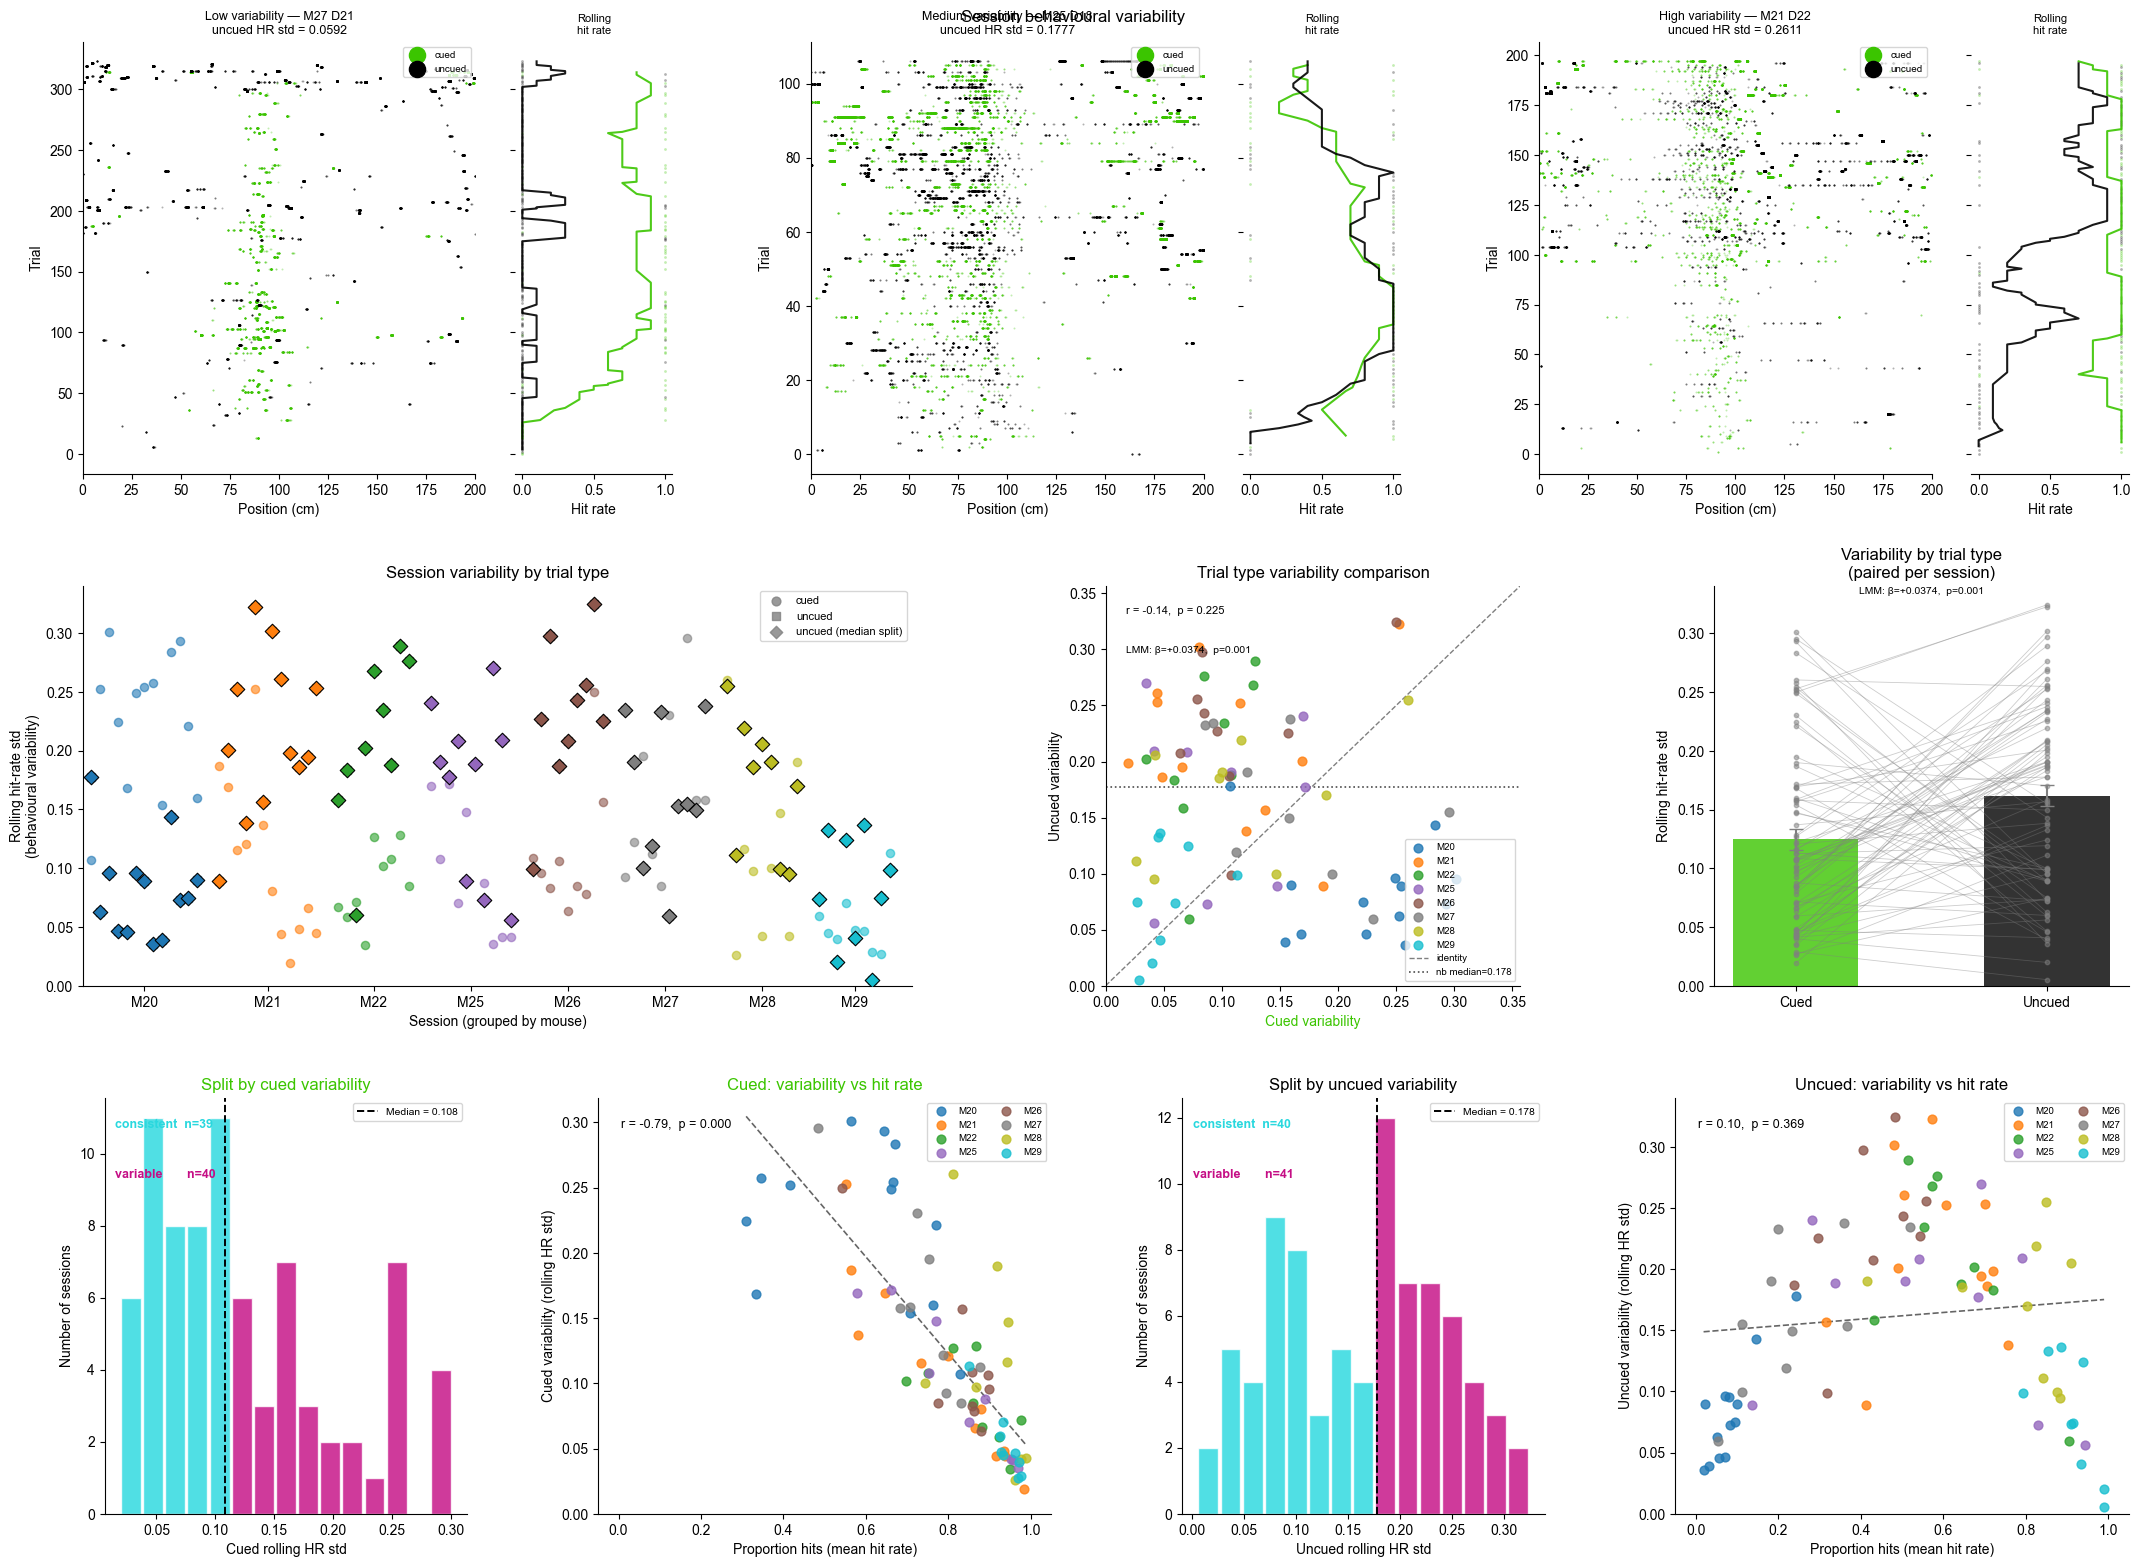

: 

In [ ]:
from scipy.stats import sem as scipy_sem, pearsonr, linregress
import statsmodels.formula.api as smf
import matplotlib.gridspec as gridspec

TRIAL_TYPES   = ['b', 'nb']
COLOR_B       = '#3bc500'
COLOR_NB      = 'black'
COLOR_CONSIST = '#29d8de'
COLOR_VAR     = '#C50E85'

# ── Rolling hit-rate variability per session ──────────────────────────────────
session_variability = {}
session_var_by_type = {}

for mouse, days in mouse_days.items():
    for day in days:
        try:
            vr_folder = f'{source_path}M{mouse}/D{day:02}/VR/'
            beh_path  = vr_folder + f"sub-{mouse}_day-{day:02}_ses-VR_beh.nwb"
            beh       = nap.load_file(beh_path)
            trials    = beh['trials']
            type_vars = {}
            for tt in TRIAL_TYPES:
                mask  = trials['type'] == tt
                hits  = (trials['performance'][mask] == 'hit').astype(float).values
                if len(hits) < 10:
                    type_vars[tt] = np.nan
                    continue
                rolling_hr    = pd.Series(hits).rolling(20, min_periods=5).mean().dropna().values
                type_vars[tt] = float(np.std(rolling_hr))
            session_var_by_type[(mouse, day)] = type_vars
            session_variability[(mouse, day)] = type_vars.get('nb', np.nan)
            print(f"  M{mouse} D{day}:  b={type_vars.get('b', np.nan):.4f}  "
                  f"nb={type_vars.get('nb', np.nan):.4f}")
        except Exception as e:
            session_variability[(mouse, day)] = np.nan
            session_var_by_type[(mouse, day)] = {tt: np.nan for tt in TRIAL_TYPES}
            print(f"  M{mouse} D{day}: FAILED — {e}")

valid_vars = [v for v in session_variability.values() if not np.isnan(v)]
median_nb  = float(np.median(valid_vars))
print(f"\nMedian uncued variability: {median_nb:.3f}  (n={len(valid_vars)} sessions)")

for df in [all_gcs2, all_ngs2]:
    df['beh_variability'] = [
        session_variability.get((int(r['mouse']), int(r['day'])), np.nan)
        for _, r in df.iterrows()
    ]
    df['beh_group'] = np.where(df['beh_variability'] >= median_nb, 'variable', 'consistent')
    df.loc[df['beh_variability'].isna(), 'beh_group'] = None

# ── Hit rate per session / trial type ─────────────────────────────────────────
session_hitrate_by_type = {}

for mouse, days in mouse_days.items():
    for day in days:
        try:
            vr_folder = f'{source_path}M{mouse}/D{day:02}/VR/'
            beh_path  = vr_folder + f"sub-{mouse}_day-{day:02}_ses-VR_beh.nwb"
            beh_nwb   = nap.load_file(beh_path)
            trials    = beh_nwb['trials']
            type_hr   = {}
            for tt in TRIAL_TYPES:
                mask = trials['type'] == tt
                hits = (trials['performance'][mask] == 'hit').astype(float).values
                type_hr[tt] = float(np.mean(hits)) if len(hits) >= 5 else np.nan
            session_hitrate_by_type[(mouse, day)] = type_hr
        except Exception:
            session_hitrate_by_type[(mouse, day)] = {tt: np.nan for tt in TRIAL_TYPES}

# ── Misc setup ────────────────────────────────────────────────────────────────
mouse_ids    = sorted(mouse_days.keys())
mouse_colors = plt.cm.tab10(np.linspace(0, 1, len(mouse_ids)))
color_map    = dict(zip(mouse_ids, mouse_colors))

b_all  = np.array([session_var_by_type[k].get('b',  np.nan) for k in session_var_by_type])
b_all  = b_all[~np.isnan(b_all)]
nb_all = np.array(valid_vars)
median_b = float(np.median(b_all))

# ── Paired b / nb values + LMM (needed for Row 1) ────────────────────────────
b_vals, nb_vals, pt_colors = [], [], []
lmm_rows = []
for mouse in mouse_ids:
    for day in mouse_days[mouse]:
        type_vs = session_var_by_type.get((mouse, day), {})
        bv  = type_vs.get('b',  np.nan)
        nbv = type_vs.get('nb', np.nan)
        if not np.isnan(bv) and not np.isnan(nbv):
            b_vals.append(bv); nb_vals.append(nbv)
            pt_colors.append(color_map[mouse])
        for tt_code, tt in [(0, 'b'), (1, 'nb')]:
            v = type_vs.get(tt, np.nan)
            if not np.isnan(v):
                lmm_rows.append({'mouse': mouse,
                                 'trial_type_code': float(tt_code),
                                 'variability': v})

b_vals  = np.array(b_vals)
nb_vals = np.array(nb_vals)

lmm_df = pd.DataFrame(lmm_rows)
try:
    lmm_res  = smf.mixedlm("variability ~ trial_type_code",
                            data=lmm_df, groups=lmm_df['mouse']
                            ).fit(reml=False, method='lbfgs', disp=False)
    lmm_coef = float(lmm_res.params['trial_type_code'])
    lmm_p    = float(lmm_res.pvalues['trial_type_code'])
    lmm_str  = f'LMM: β={lmm_coef:+.4f},  p={lmm_p:.3f}'
except Exception as e:
    lmm_str  = f'LMM failed: {e}'
    lmm_coef, lmm_p = np.nan, np.nan
print(f"\n{lmm_str}")

# ── Example sessions ──────────────────────────────────────────────────────────
sorted_sessions = sorted(
    [(k, v) for k, v in session_variability.items() if not np.isnan(v)],
    key=lambda x: x[1]
)
n = len(sorted_sessions)
example_sessions = [
    ('Low',    sorted_sessions[max(0, n // 10)]),
    ('Medium', sorted_sessions[n // 2]),
    ('High',   sorted_sessions[min(n - 1, 9 * n // 10)]),
]
print("\nExample sessions:")
for label, ((mouse, day), var) in example_sessions:
    print(f"  {label:6s}: M{mouse} D{day}  nb_var={var:.4f}")


# ── Helper functions ──────────────────────────────────────────────────────────
def _plot_stop_raster(ax, beh):
    trial_numbers = np.array(beh['trial_number'])
    position      = np.array(beh['P'])
    speed         = np.array(beh['S'])
    stop_mask     = speed < 3
    min_len       = min(len(trial_numbers), len(position), len(stop_mask))
    trial_numbers = trial_numbers[:min_len]
    position      = position[:min_len]
    stop_mask     = stop_mask[:min_len]
    for i, ti in enumerate(beh['trials'].index):
        t_num   = beh['trials'][ti]['number'].iloc[0]
        t_type  = beh['trials'][ti]['type'].iloc[0]
        tn_mask = trial_numbers == t_num
        stops   = position[stop_mask & tn_mask]
        if len(stops) == 0:
            continue
        ax.scatter(stops, i * np.ones(len(stops)),
                   c=COLOR_B if t_type == 'b' else COLOR_NB,
                   s=2, alpha=0.3, rasterized=True, linewidths=0)
    ax.set_xlim(0, tl)
    ax.invert_yaxis()
    ax.scatter([], [], c=COLOR_B,  s=15, label='cued')
    ax.scatter([], [], c=COLOR_NB, s=15, label='uncued')
    ax.legend(fontsize=7, loc='upper right', markerscale=3)
    ax.set_xlabel('Position (cm)')
    ax.set_ylabel('Trial')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)


def _plot_rolling_hr(ax, beh):
    for tt, color in [('b', COLOR_B), ('nb', COLOR_NB)]:
        tt_indices, tt_hits = [], []
        for i, ti in enumerate(beh['trials'].index):
            if beh['trials'][ti]['type'].iloc[0] == tt:
                tt_indices.append(i)
                tt_hits.append(1.0 if beh['trials'][ti]['performance'].iloc[0] == 'hit' else 0.0)
        if len(tt_hits) < 3:
            continue
        rolling = pd.Series(tt_hits).rolling(10, min_periods=3).mean().values
        ax.plot(rolling, tt_indices, color=color, linewidth=1.5, alpha=0.9)
        ax.scatter(tt_hits, tt_indices,
                   c=color, s=4, alpha=0.3, rasterized=True, linewidths=0)
    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel('Hit rate')
    ax.tick_params(labelleft=False)
    ax.invert_yaxis()
    for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)


# ── Figure layout — 3 rows ────────────────────────────────────────────────────
# Row 0 (gs_top): raster0 | hr0 | GAP | raster1 | hr1 | GAP | raster2 | hr2
# Row 1 (gs_mid): per-session scatter | cued vs uncued scatter | paired bar
# Row 2 (gs_bot): dist_b | scatter_b | dist_nb | scatter_nb
fig = plt.figure(figsize=(22, 16))

gs_top = gridspec.GridSpec(
    1, 8, figure=fig,
    width_ratios=[3, 1.2, 0.45, 3, 1.2, 0.45, 3, 1.2],
    left=0.05, right=0.98, top=0.97, bottom=0.70,
    wspace=0.18,
)
gs_mid = gridspec.GridSpec(
    1, 3, figure=fig,
    width_ratios=[3, 1.5, 1.5],
    left=0.05, right=0.98, top=0.63, bottom=0.38,
    wspace=0.35,
)
gs_bot = gridspec.GridSpec(
    1, 4, figure=fig,
    width_ratios=[2, 2.5, 2, 2.5],
    left=0.06, right=0.98, top=0.31, bottom=0.05,
    wspace=0.32,
)

# ── Row 0: example stop rasters ───────────────────────────────────────────────
for col, (var_label, ((mouse, day), var_val)) in enumerate(example_sessions):
    ax_r = fig.add_subplot(gs_top[0, [0, 3, 6][col]])
    ax_h = fig.add_subplot(gs_top[0, [1, 4, 7][col]], sharey=ax_r)
    try:
        _, _, _, _, beh, _ = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
        _plot_stop_raster(ax_r, beh)
        _plot_rolling_hr(ax_h, beh)
    except Exception as e:
        ax_r.text(0.5, 0.5, f'Error\n{e}', transform=ax_r.transAxes,
                  ha='center', va='center', fontsize=7)
    ax_r.set_title(
        f'{var_label} variability — M{mouse} D{day}\n'
        f'uncued HR std = {var_val:.4f}', fontsize=9)
    ax_h.set_title('Rolling\nhit rate', fontsize=8)

# ── Row 1: per-session scatter | cued vs uncued scatter | paired bar ──────────
type_markers = {'b': 'o', 'nb': 's', 'mean': 'D'}

# Col 0: per-session variability scatter
ax = fig.add_subplot(gs_mid[0, 0])
x, x_tick_positions, x_tick_labels = 0, [], []
for mouse in mouse_ids:
    xs_all = []
    for day in mouse_days[mouse]:
        nb_v = session_variability.get((mouse, day), np.nan)
        if np.isnan(nb_v):
            continue
        type_vs = session_var_by_type.get((mouse, day), {})
        for tt in TRIAL_TYPES:
            v = type_vs.get(tt, np.nan)
            if not np.isnan(v):
                ax.scatter(x, v, color=color_map[mouse], marker=type_markers[tt],
                           s=35, alpha=0.6, zorder=3)
        ax.scatter(x, nb_v, color=color_map[mouse], marker=type_markers['mean'],
                   s=55, zorder=4, edgecolors='k', linewidths=0.8)
        xs_all.append(x); x += 1
    if xs_all:
        x_tick_positions.append(np.mean(xs_all))
        x_tick_labels.append(f'M{mouse}')
        x += 1.5
for tt, lbl in [('b', 'cued'), ('nb', 'uncued'), ('mean', 'uncued (median split)')]:
    ax.scatter([], [], color='grey', marker=type_markers[tt], s=40, label=lbl, alpha=0.8)
ax.set_xticks(x_tick_positions); ax.set_xticklabels(x_tick_labels)
ax.set_xlim(-1, x); ax.set_ylim(bottom=0)
ax.set_xlabel('Session (grouped by mouse)')
ax.set_ylabel('Rolling hit-rate std\n(behavioural variability)')
ax.set_title('Session variability by trial type')
ax.legend(fontsize=8, loc='upper right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# Col 1: cued vs uncued variability scatter
ax = fig.add_subplot(gs_mid[0, 1])
for mouse in mouse_ids:
    idx = [i for i, c in enumerate(pt_colors) if np.allclose(c, color_map[mouse])]
    if idx:
        ax.scatter(b_vals[idx], nb_vals[idx], color=color_map[mouse],
                   s=40, alpha=0.8, label=f'M{mouse}', zorder=3)
lim = max(b_vals.max(), nb_vals.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='identity')
ax.axhline(median_nb, color=COLOR_NB, linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'nb median={median_nb:.3f}')
if len(b_vals) >= 3:
    r, p_r = pearsonr(b_vals, nb_vals)
    ax.text(0.05, 0.95, f'r = {r:.2f},  p = {p_r:.3f}',
            transform=ax.transAxes, fontsize=8, va='top')
    ax.text(0.05, 0.85, lmm_str, transform=ax.transAxes, fontsize=7.5, va='top')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Cued variability',   color=COLOR_B)
ax.set_ylabel('Uncued variability', color=COLOR_NB)
ax.set_title('Trial type variability comparison')
ax.legend(fontsize=7, loc='lower right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# Col 2: paired bar plot
ax = fig.add_subplot(gs_mid[0, 2])
means = [b_vals.mean(), nb_vals.mean()]
sems  = [scipy_sem(b_vals), scipy_sem(nb_vals)]
ax.bar([0, 1], means, yerr=sems, width=0.5, color=[COLOR_B, COLOR_NB], alpha=0.8,
       capsize=5, error_kw=dict(linewidth=1.5, ecolor='grey'))
for bv, nbv in zip(b_vals, nb_vals):
    ax.plot([0, 1], [bv, nbv], color='grey', linewidth=0.6, alpha=0.4, zorder=2)
    ax.scatter([0, 1], [bv, nbv], color='grey', s=10, alpha=0.5, zorder=3)
y_top = max(b_vals.max(), nb_vals.max()) * 1.08
ax.annotate('', xy=(1, y_top), xytext=(0, y_top),
            arrowprops=dict(arrowstyle='-', color='k', lw=1.2))
ax.text(0.5, y_top * 0.97, lmm_str, ha='center', va='top', fontsize=7.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Cued', 'Uncued'])
ax.set_ylabel('Rolling hit-rate std')
ax.set_title('Variability by trial type\n(paired per session)')
ax.set_ylim(bottom=0)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# ── Row 2: distributions + variability vs hit rate ────────────────────────────
tt_configs = [
    ('b',  COLOR_B,  'Cued',   b_all,  median_b,  0, 1),
    ('nb', COLOR_NB, 'Uncued', nb_all, median_nb,  2, 3),
]
for tt, tt_color, label, data_all, med, dist_col, scat_col in tt_configs:

    ax = fig.add_subplot(gs_bot[0, dist_col])
    n_c = int(np.sum(data_all < med))
    n_v = int(np.sum(data_all >= med))
    counts, bin_edges = np.histogram(data_all, bins=15)
    for bc, lo, hi in zip(counts, bin_edges[:-1], bin_edges[1:]):
        face = COLOR_CONSIST if (lo + hi) / 2 < med else COLOR_VAR
        ax.bar((lo + hi) / 2, bc, width=(hi - lo) * 0.9,
               color=face, alpha=0.82, edgecolor='white')
    ax.axvline(med, color='k', linestyle='--', linewidth=1.4,
               label=f'Median = {med:.3f}')
    ax.text(0.03, 0.95, f'consistent  n={n_c}', transform=ax.transAxes,
            color=COLOR_CONSIST, fontsize=9, va='top', fontweight='bold')
    ax.text(0.03, 0.83, f'variable       n={n_v}', transform=ax.transAxes,
            color=COLOR_VAR,     fontsize=9, va='top', fontweight='bold')
    ax.set_xlabel(f'{label} rolling HR std')
    ax.set_ylabel('Number of sessions')
    ax.set_title(f'Split by {label.lower()} variability', color=tt_color)
    ax.legend(fontsize=7.5)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

    ax = fig.add_subplot(gs_bot[0, scat_col])
    all_hr  = np.array([session_hitrate_by_type[k].get(tt, np.nan)
                        for k in session_hitrate_by_type])
    all_var = np.array([session_var_by_type[k].get(tt, np.nan)
                        for k in session_var_by_type])
    valid   = ~np.isnan(all_hr) & ~np.isnan(all_var)
    for mouse in mouse_ids:
        var_list, hr_list = [], []
        for day in mouse_days[mouse]:
            v  = session_var_by_type.get((mouse, day), {}).get(tt, np.nan)
            hr = session_hitrate_by_type.get((mouse, day), {}).get(tt, np.nan)
            if not np.isnan(v) and not np.isnan(hr):
                var_list.append(v); hr_list.append(hr)
        if var_list:
            ax.scatter(hr_list, var_list, color=color_map[mouse],
                       s=40, alpha=0.8, label=f'M{mouse}', zorder=3)
    if valid.sum() >= 3:
        r, p_r = pearsonr(all_hr[valid], all_var[valid])
        slope, intercept, *_ = linregress(all_hr[valid], all_var[valid])
        x_fit = np.linspace(all_hr[valid].min(), all_hr[valid].max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, 'k--', linewidth=1.2, alpha=0.6)
        ax.text(0.05, 0.95, f'r = {r:.2f},  p = {p_r:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
    ax.set_xlabel('Proportion hits (mean hit rate)')
    ax.set_ylabel(f'{label} variability (rolling HR std)')
    ax.set_title(f'{label}: variability vs hit rate', color=tt_color)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

fig.suptitle('Session behavioural variability', fontsize=12, y=0.99)
plt.savefig('session_beh_variability.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Task-anchoring metrics along the medial-lateral axis

### Overview

For every GC and NGS cell across all sessions we compute two complementary
metrics that describe *how* a cell expresses task-anchoring, then ask whether
those metrics vary systematically with the cell's position along the
medial-lateral axis of the superior colliculus (SC).

---

### Metric 1 — Dominance (fraction of sessions a cell is stably anchored)

A cell is called **dominant** if it spends more than 90 % of trials in a
single anchor state — either almost always anchored (abundance > 0.9) or
almost always non-anchored (abundance < 0.1).

$$\text{is\_dominant} = \mathbf{1}\bigl[\text{abundance} > 0.9 \;\cup\; \text{abundance} < 0.1\bigr]$$

The top row of the figure shows, for each position bin along the
medial-lateral axis, the **fraction of cells that are dominant**. Faint lines
show individual sessions; the bold line is the population mean ± SEM across
all sessions in that bin. This tells us whether medial or lateral cells are
more likely to be "committed" to a single anchor mode throughout a session.

---

### Metric 2 — Streakiness (temporal persistence of label switching)

For cells that *do* switch between anchored and non-anchored states
(10 % ≤ abundance ≤ 90 %, i.e. non-dominant cells), we ask: are the
transitions random, or does the cell tend to stay in the same state for
several trials in a row (a "streak")?

We quantify this with the **lag-1 autocorrelation** of the binary
trial-label sequence:

$$\text{streakiness} = \text{corr}(l_t,\, l_{t+1})$$

| Value | Interpretation |
|-------|---------------|
| ≈ 0 | Labels switch randomly from trial to trial |
| > 0 | Persistent — cell stays anchored (or non-anchored) for runs of trials |
| < 0 | Alternating — cell flips state almost every trial |

The bottom row shows the streakiness of non-dominant cells as a function of
medial-lateral position. Each point is one cell; the bold line is the binned
mean ± SEM. The dashed horizontal line marks zero (random switching).

---

### Medial-lateral position

All cells have a registered coordinate `SC_x` (µm from the midline, sign
corrected so lateral is positive). Position bins of 800 µm are used. The
vertical dashed line at **3 400 µm** marks the conventional
medial / lateral boundary used elsewhere in the project.

---

### Statistics

Each panel reports a **Spearman ρ** between the raw (unbinned) per-cell
metric and `SC_x_abs`, testing for a monotonic medial-to-lateral trend.
Significance thresholds: `*` p < 0.05, `**` p < 0.01, `***` p < 0.001,
`ns` otherwise.


In [4]:
# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41],
    25: [16,17,18,25],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

# --- Three 2x2 task-anchoring agreement matrices ---
# GCS-only, NGS-only, and GCS+NGS pooled.
# Rows/Cols = medial vs lateral.
# Each cell = mean pairwise agreement between same-session cell pairs at those
# positions. Self-pairs (same cluster_id in same session) are excluded.

PEAKS = [12, 28, 44, 60, 76]
POSITIONS = ['medial', 'lateral']

# Build position lookups
gcs_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_gcs.iterrows()
}
ngs_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_ngs.iterrows()
}
all_cells_df = pd.concat([all_gcs, all_ngs], ignore_index=True)
all_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_cells_df.iterrows()
}

# agreement_lists for each group
gcs_agr     = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}
ngs_agr     = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}
pooled_agr  = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}

def _compute_pairwise(cell_labels, agr_dict):
    cell_ids = list(cell_labels.keys())
    for i, cid_a in enumerate(cell_ids):
        lab_a, pos_a = cell_labels[cid_a]
        for cid_b in cell_ids[i + 1:]:
            lab_b, pos_b = cell_labels[cid_b]
            n = min(len(lab_a), len(lab_b))
            if n == 0:
                continue
            agr = np.mean(lab_a[:n] == lab_b[:n])
            agr_dict[(pos_a, pos_b)].append(agr)
            if pos_a != pos_b:
                agr_dict[(pos_b, pos_a)].append(agr)

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        try:
            gcs, ngs, all_cells = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Skipping: {e}")
            continue

        def _get_labels(cluster_id):
            tc = tcs.get(cluster_id)
            if tc is None:
                return None
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            results = spectral_analysis({cluster_id: tc, 1000: tc}, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_idx = np.isin(max_peaks, PEAKS).astype(int)
            return get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)

        def _build_cell_labels(cids, pos_map):
            cell_labels = {}
            for cid in cids:
                pos = pos_map.get((mouse, day, int(cid)))
                if pos is None:
                    continue
                try:
                    lab = _get_labels(cid)
                    if lab is not None:
                        cell_labels[cid] = (lab, pos)
                except Exception:
                    continue
            return cell_labels

        gcs_labels    = _build_cell_labels(gcs.cluster_id.values, gcs_pos_map)
        ngs_labels    = _build_cell_labels(ngs.cluster_id.values, ngs_pos_map)
        pooled_cids   = np.concatenate([gcs.cluster_id.values, ngs.cluster_id.values])
        pooled_labels = _build_cell_labels(pooled_cids, all_pos_map)

        _compute_pairwise(gcs_labels,    gcs_agr)
        _compute_pairwise(ngs_labels,    ngs_agr)
        _compute_pairwise(pooled_labels, pooled_agr)

# Build the three 2x2 matrices
def _build_matrix(agr_dict):
    matrix = np.full((2, 2), np.nan)
    for r, pos_row in enumerate(POSITIONS):
        for c, pos_col in enumerate(POSITIONS):
            vals = agr_dict[(pos_row, pos_col)]
            if vals:
                matrix[r, c] = np.mean(vals)
    return matrix

matrix_gcs    = _build_matrix(gcs_agr)
matrix_ngs    = _build_matrix(ngs_agr)
matrix_pooled = _build_matrix(pooled_agr)

print("GCS agreement matrix:")
print(matrix_gcs)
print("\nNGS agreement matrix:")
print(matrix_ngs)
print("\nGCS+NGS pooled agreement matrix:")
print(matrix_pooled)

# Plot side-by-side
titles   = ['GCS', 'NGS', 'GCS + NGS']
matrices = [matrix_gcs, matrix_ngs, matrix_pooled]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix, vmin=0.5, vmax=1.0, cmap='RdPu')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(POSITIONS, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(POSITIONS, fontsize=10)
    ax.set_xlabel('Cell position', fontsize=10)
    ax.set_ylabel('Cell position', fontsize=10)
    for r in range(2):
        for c in range(2):
            val = matrix[r, c]
            ax.text(c, r, f'{val:.3f}' if not np.isnan(val) else 'nan',
                    ha='center', va='center', fontsize=11,
                    color='white' if val > 0.75 else 'black')
    plt.colorbar(im, ax=ax, label='Mean agreement', shrink=0.8)
    ax.set_title(f'Task-anchoring agreement\n({title})', fontsize=10)

plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_agreement_matrix.pdf'
)
plt.show()


Processing Mouse 20 Day 14...
Processing Mouse 20 Day 15...
Processing Mouse 20 Day 16...
Processing Mouse 20 Day 17...
Processing Mouse 20 Day 18...
Processing Mouse 20 Day 19...
Processing Mouse 20 Day 20...
Processing Mouse 20 Day 21...
Processing Mouse 20 Day 22...
Processing Mouse 20 Day 23...
Processing Mouse 20 Day 24...
Processing Mouse 20 Day 25...
Processing Mouse 20 Day 26...
Processing Mouse 21 Day 15...
Processing Mouse 21 Day 16...
Processing Mouse 21 Day 17...
Processing Mouse 21 Day 18...
Processing Mouse 21 Day 19...
Processing Mouse 21 Day 20...
Processing Mouse 21 Day 21...
Processing Mouse 21 Day 22...
Processing Mouse 21 Day 23...
Processing Mouse 21 Day 24...
Processing Mouse 21 Day 25...
Processing Mouse 21 Day 26...
Processing Mouse 22 Day 33...
Processing Mouse 22 Day 34...
Processing Mouse 22 Day 35...
Processing Mouse 22 Day 36...
Processing Mouse 22 Day 37...
Processing Mouse 22 Day 38...
Processing Mouse 22 Day 39...


AttributeError: 'DataFrame' object has no attribute 'cluster_id'

In [ ]:
multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41],
    25: [16,17,18,25],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

In [ ]:

# --- Three 4x4 task-anchoring agreement matrices (by shank) ---
# GCS-only, NGS-only, and GCS+NGS pooled.
# Rows/Cols = shank 0, 1, 2, 3 (medial to lateral).
# Each cell = mean pairwise agreement between same-session cell pairs on those shanks.
# Self-pairs (same cluster_id in same session) are excluded.

PEAKS  = [12, 28, 44, 60, 76]
SHANKS = [0, 1, 2, 3]

# Build shank lookup maps from the abundance DataFrames (already have shank info via SC_x)
# We need to call reconstruct_shank_id per session, so we build maps on the fly below.

gcs_shank_agr    = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}
ngs_shank_agr    = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}
pooled_shank_agr = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}

def _compute_pairwise_shank(cell_labels, agr_dict):
    cell_ids = list(cell_labels.keys())
    for i, cid_a in enumerate(cell_ids):
        lab_a, shank_a = cell_labels[cid_a]
        for cid_b in cell_ids[i + 1:]:
            lab_b, shank_b = cell_labels[cid_b]
            n = min(len(lab_a), len(lab_b))
            if n == 0:
                continue
            agr = np.mean(lab_a[:n] == lab_b[:n])
            agr_dict[(shank_a, shank_b)].append(agr)
            if shank_a != shank_b:
                agr_dict[(shank_b, shank_a)].append(agr)

for mouse, days in multishank_mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        try:
            gcs, ngs, all_cells = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Skipping: {e}")
            continue

        # Assign shank IDs
        gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
        ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')

        # Build shank lookup maps for this session
        gcs_shank_map = {int(r['cluster_id']): int(r['shank_id']) for _, r in gcs.iterrows()}
        ngs_shank_map = {int(r['cluster_id']): int(r['shank_id']) for _, r in ngs.iterrows()}
        all_shank_map = {**gcs_shank_map, **ngs_shank_map}

        def _get_labels_sh(cluster_id):
            tc = tcs.get(cluster_id)
            if tc is None:
                return None
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            results = spectral_analysis({cluster_id: tc, 1000: tc}, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_idx = np.isin(max_peaks, PEAKS).astype(int)
            return get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)

        def _build_shank_labels(cids, shank_map):
            cell_labels = {}
            for cid in cids:
                shank = shank_map.get(int(cid))
                if shank is None:
                    continue
                try:
                    lab = _get_labels_sh(cid)
                    if lab is not None:
                        cell_labels[cid] = (lab, shank)
                except Exception:
                    continue
            return cell_labels

        gcs_labels    = _build_shank_labels(gcs.cluster_id.values, gcs_shank_map)
        ngs_labels    = _build_shank_labels(ngs.cluster_id.values, ngs_shank_map)
        pooled_cids   = np.concatenate([gcs.cluster_id.values, ngs.cluster_id.values])
        pooled_labels = _build_shank_labels(pooled_cids, all_shank_map)

        _compute_pairwise_shank(gcs_labels,    gcs_shank_agr)
        _compute_pairwise_shank(ngs_labels,    ngs_shank_agr)
        _compute_pairwise_shank(pooled_labels, pooled_shank_agr)

# Build the three 4x4 matrices
def _build_shank_matrix(agr_dict):
    matrix = np.full((4, 4), np.nan)
    for r, s_row in enumerate(SHANKS):
        for c, s_col in enumerate(SHANKS):
            vals = agr_dict[(s_row, s_col)]
            if vals:
                matrix[r, c] = np.mean(vals)
    return matrix

matrix_gcs_sh    = _build_shank_matrix(gcs_shank_agr)
matrix_ngs_sh    = _build_shank_matrix(ngs_shank_agr)
matrix_pooled_sh = _build_shank_matrix(pooled_shank_agr)

shank_labels = [f'S{s}' for s in SHANKS]
print("GCS shank agreement matrix:")
print(matrix_gcs_sh)
print("\nNGS shank agreement matrix:")
print(matrix_ngs_sh)
print("\nGCS+NGS pooled shank agreement matrix:")
print(matrix_pooled_sh)

# --- Plot ---
titles_sh   = ['GCS', 'NGS', 'GCS + NGS']
matrices_sh = [matrix_gcs_sh, matrix_ngs_sh, matrix_pooled_sh]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, matrix, title in zip(axes, matrices_sh, titles_sh):
    im = ax.imshow(matrix, vmin=0.5, vmax=1.0, cmap='RdPu')
    ax.set_xticks(range(4))
    ax.set_xticklabels(shank_labels, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(shank_labels, fontsize=9)
    ax.set_xlabel('Shank', fontsize=10)
    ax.set_ylabel('Shank', fontsize=10)
    for r in range(4):
        for c in range(4):
            val = matrix[r, c]
            txt = f'{val:.3f}' if not np.isnan(val) else 'nan'
            ax.text(c, r, txt, ha='center', va='center', fontsize=8,
                    color='white' if (not np.isnan(val) and val > 0.75) else 'black')
    plt.colorbar(im, ax=ax, label='Mean agreement', shrink=0.8)
    ax.set_title(f'Task-anchoring agreement by shank\n({title})', fontsize=9)

plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_shank_agreement_matrix.pdf'
)
plt.show()
